> Split from `submission.ipynb`. TCGA modelling notebook. Conceptually run after 03_tcga_eda.ipynb; this notebook also rebuilds the modelling cohort from raw files.

> Original cell range: `112` to `158`.


# TCGA Pan-Cancer Modeling for Predicting TP53 Mutation Status from RNA Expression

This notebook builds a leakage-aware workflow for predicting **TP53 mutation status** from **TCGA RNA expression**.

Cancer type is used only as a **stratification/grouping/audit variable**, not as a predictor on the same level as mRNA.

## Main goals

- build a **tumour-only**, **one-sample-per-patient** TCGA cohort;
- define **TP53 nonsynonymous mutation status** from mutation annotations;
- train RNA-only Task 1 and Task 2 models;
- use adaptive TP53 × cancer-type stratification for train/test splits;
- run cancer-type-grouped CV as an anti-confounding robustness check;
- run RNA-only ablation / ensemble models, using cuML when available and falling back safely when it is not.


In [55]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import gzip
import os
import re
import sys
import subprocess
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)

In [56]:
# Search locations for Kaggle, Colab, local, and this sandbox.
# The first Kaggle path below matches the path seen in the previously successful run.
SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/cameroncaputa/tp53-prediction"),
    Path("/kaggle/input/tp53-prediction"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file.\nTried:\n" + "\n".join(tried))
    return None

# Prefer raw TCGA/Xena files when available.
RAW_MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3.v0.2.8.PUBLIC.xena",
    "*mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3*PUBLIC*xena*",
], required=False)

RAW_PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=False)

RAW_RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "tcga_RSEM_gene_tpm.gz",
    "*tcga_RSEM_gene_tpm*",
], required=False)

# Curated CSV fallbacks.
MODEL_PATH = find_first(["Model.csv", "*Model*.csv"], required=False)
OMICS_MUT_PATH = find_first([
    "OmicsSomaticMutations.csv",
    "*OmicsSomaticMutations*.csv",
], required=False)
OMICS_RNA_PATH = find_first([
    "OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    "OmicsExpressionProteinCodingGenesTPML.csv",
    "*OmicsExpressionProteinCodingGenesTPM*.csv",
    "*OmicsExpressionProteinCodingGenesTPML*",
], required=False)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

USE_RAW_TCGA = all(p is not None for p in [RAW_MUT_PATH, RAW_PHENO_PATH, RAW_RNA_PATH])

MUT_PATH = RAW_MUT_PATH if RAW_MUT_PATH is not None else OMICS_MUT_PATH
META_PATH = RAW_PHENO_PATH if RAW_PHENO_PATH is not None else MODEL_PATH
RNA_PATH = RAW_RNA_PATH if RAW_RNA_PATH is not None else OMICS_RNA_PATH

def show_available_kaggle_files(max_files=80):
    roots = [Path("/kaggle/input"), Path("/kaggle/input/datasets")]
    shown = 0
    print("\nAvailable files under Kaggle input roots:")
    for root in roots:
        if not root.exists():
            continue
        for p in sorted(root.rglob("*")):
            if p.is_file():
                print(" -", p)
                shown += 1
                if shown >= max_files:
                    print(f" ... truncated after {max_files} files")
                    return
    if shown == 0:
        print("No files found under /kaggle/input. Attach the TCGA raw-data Kaggle Dataset to this notebook.")

missing_inputs = []
if MUT_PATH is None:
    missing_inputs.append("mutation file: mc3.v0.2.8.PUBLIC.xena")
if META_PATH is None:
    missing_inputs.append("metadata/phenotype file: Survival_SupplementalTable_S1_20171025_xena_sp")
if RNA_PATH is None:
    missing_inputs.append("RNA expression file: tcga_RSEM_gene_tpm")

if missing_inputs:
    show_available_kaggle_files()
    raise FileNotFoundError(
        "Could not locate required TCGA input files. Missing:\n  - "
        + "\n  - ".join(missing_inputs)
        + "\n\nAttach the same Kaggle Dataset used in the successful run, which contained:\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm\n"
        + "Optional but recommended: tp53_target_genes_fischer2017.csv"
    )

RANDOM_STATE = 42
TEST_SIZE = 0.20
INNER_CV_SPLITS = 3
GROUP_CV_SPLITS = 3
TOP_COEFS_TO_SHOW = 25
TOP_VAR_GENES = min(3000, TCGA_MODEL_RNA_FEATURE_CAP)
FLOOR_VALUE = -9.9658
MAX_FLOOR_FRAC = 0.95
BOOTSTRAP_RESAMPLES = 200
MIN_SAMPLES_PER_CLASS = 20
SKLEARN_MAX_ITER = 10000
CUML_MAX_ITER = 10000
SAGA_TOL = 1e-3
CUML_TOL = 1e-4

RUN_GROUPED_CV = True
RUN_COMBINED_MODEL = False
RUN_WITHIN_CANCER_EVAL = False

# Runtime controls
GPU_REQUIRED = False
ALLOW_CPU_FALLBACK = True
INSTALL_RAPIDS_IN_COLAB = False
GPU_SEARCH_BACKEND = "cuml"      # {"cuml", "sklearn"}
FINAL_REFIT_BACKEND = "sklearn"  # {"sklearn", "cuml"}; sklearn is more reproducible for final reported fits
WITHIN_CANCER_BACKEND = "sklearn"   # {"cuml", "sklearn"}; fixed-parameter within-cancer checks favor reproducibility
GROUPED_TUNING_MODE = "reuse_holdout_best"  # {"nested", "reuse_holdout_best"}; nested is slower but methodologically cleaner


RNA_PARAM_GRID = {
    "top_k": [3000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5],
}

# Smaller pre-specified grids for nested cancer-type-grouped evaluation.
# This keeps the stricter grouped analysis feasible while avoiding reuse of random-holdout hyperparameters.
GROUPED_RNA_PARAM_GRID = {
    "top_k": [3000],
    "k_select": [500],
    "scaler": ["maxabs"],
    "C": [0.1],
    "l1_ratio": [0.0, 0.5],
}

print("Using raw TCGA/Xena inputs:", USE_RAW_TCGA)
print("TCGA_MODEL_RNA_FEATURE_CAP:", TCGA_MODEL_RNA_FEATURE_CAP)
print("MUT_PATH =", MUT_PATH)
print("META_PATH =", META_PATH)
print("RNA_PATH =", RNA_PATH)
print("TP53_TARGETS_PATH =", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH =", GENE_ANNOTATION_PATH)
print("RNA grid combinations:", len(list(ParameterGrid(RNA_PARAM_GRID))))
print("Grouped RNA grid combinations:", len(list(ParameterGrid(GROUPED_RNA_PARAM_GRID))))


Using raw TCGA/Xena inputs: True
TCGA_MODEL_RNA_FEATURE_CAP: 3000
MUT_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena
META_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp
RNA_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm
TP53_TARGETS_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH = None
RNA grid combinations: 12
Grouped RNA grid combinations: 2


The notebook uses a hybrid backend strategy. GPU-accelerated cuML is used for the repeated hyperparameter-search fits, where speed matters most. However, the final refit and within-cancer analyses are run with scikit-learn. These stages are used for the final reported estimates, coefficients, calibration, and subgroup results, so numerical stability, clearer convergence diagnostics, and reproducibility are more important than speed. This is especially relevant because some within-cancer subsets are small or highly imbalanced, where GPU overhead and solver behavior may be less reliable. Thus, cuML is used as an acceleration tool for model search, while scikit-learn is used as the reference implementation for final reporting.

## GPU environment setup

The heavy RNA and combined-model searches can use **RAPIDS cuML** if it is available in the runtime.

- If RAPIDS is installed and importable, the manual elastic-net search can use **cuML LogisticRegression**.
- If RAPIDS is unavailable, the notebook falls back to **scikit-learn** automatically unless `GPU_REQUIRED=True`.
- The **final refit** defaults to **scikit-learn** for more reproducible reported holdout estimates and fewer GPU convergence-warning issues.
- The grouped cancer-type evaluation defaults to nested tuning with a smaller pre-specified grid. This is slower than reusing random-holdout hyperparameters, but it is the cleaner anti-confounding estimate.

In [57]:
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.exists("/kaggle")

if INSTALL_RAPIDS_IN_COLAB and IN_COLAB:
    utils_dir = Path("./rapidsai-csp-utils")
    if not utils_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/rapidsai/rapidsai-csp-utils.git"],
            check=True,
        )
    subprocess.run([sys.executable, "rapidsai-csp-utils/colab/pip-install.py"], check=True)

GPU_AVAILABLE = False
GPU_IMPORT_ERROR = None
cp = None
cuLogisticRegression = None
cuml = None

try:
    import cupy as cp
    import cuml
    from cuml.linear_model import LogisticRegression as cuLogisticRegression

    GPU_AVAILABLE = True
    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass
except Exception as e:
    GPU_IMPORT_ERROR = repr(e)

if GPU_REQUIRED and not GPU_AVAILABLE and not ALLOW_CPU_FALLBACK:
    raise RuntimeError(
        "GPU_REQUIRED=True but cuML/CuPy could not be imported. "
        "Install RAPIDS in a compatible CUDA environment first."
    )

if GPU_SEARCH_BACKEND == "cuml" and not GPU_AVAILABLE:
    if ALLOW_CPU_FALLBACK:
        print("cuML not available; falling back to scikit-learn CPU search.")
        GPU_SEARCH_BACKEND = "sklearn"
        if FINAL_REFIT_BACKEND == "cuml":
            FINAL_REFIT_BACKEND = "sklearn"
        if WITHIN_CANCER_BACKEND == "cuml":
            WITHIN_CANCER_BACKEND = "sklearn"
    else:
        raise RuntimeError("GPU search requested but cuML/CuPy are unavailable.")

gpu_name = None
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        text=True,
    ).strip().splitlines()
    gpu_name = smi[0] if smi else None
except Exception:
    pass

print("In Colab:", IN_COLAB)
print("In Kaggle:", IN_KAGGLE)
print("GPU available:", GPU_AVAILABLE)
print("GPU import error:", GPU_IMPORT_ERROR)
print("Detected GPU name:", gpu_name)
print("GPU search backend:", GPU_SEARCH_BACKEND)
print("Final refit backend:", FINAL_REFIT_BACKEND)
print("Within-cancer backend:", WITHIN_CANCER_BACKEND)
print("Grouped tuning mode:", GROUPED_TUNING_MODE)

In Colab: False
In Kaggle: True
GPU available: True
GPU import error: None
Detected GPU name: Tesla T4
GPU search backend: cuml
Final refit backend: sklearn
Within-cancer backend: sklearn
Grouped tuning mode: reuse_holdout_best


## Load mutation and metadata tables

The notebook first loads the mutation and metadata / phenotype tables, infers the relevant schema, and only then loads the RNA matrix after the modeling cohort is frozen.

This avoids loading the full expression matrix too early.

In [58]:
def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        line = f.readline()
    if line.count("\t") > line.count(","):
        return "\t"
    return ","

def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None

def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))

def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))

def normalize_sample_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s

def normalize_patient_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s

def tcga_sample_type_code(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan

TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan

def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

MUT_SEP = sniff_sep(MUT_PATH)
META_SEP = sniff_sep(META_PATH)
RNA_SEP = sniff_sep(RNA_PATH)

mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
meta_raw = pd.read_csv(META_PATH, sep=META_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=3, low_memory=False)

print("mut_raw shape:", mut_raw.shape)
print("meta_raw shape:", meta_raw.shape)
print("rna_header preview shape:", rna_header.shape)
print("mut_raw columns:", mut_raw.columns.tolist()[:20])
print("meta_raw columns:", meta_raw.columns.tolist()[:20])
print("RNA first columns:", list(rna_header.columns[:8]))

MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

META_SAMPLE_COL = find_col(
    meta_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "metadata sample column",
)
PATIENT_COL = find_col(
    meta_raw,
    ["patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    meta_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen metadata sample column:", META_SAMPLE_COL)
print("Chosen patient column:", PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

mut_raw shape: (2907335, 12)
meta_raw shape: (12591, 34)
rna_header preview shape: (3, 10536)
mut_raw columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
meta_raw columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']
Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect']
Chosen metadata sample column: sample
Chosen patient column: _P

## Infer RNA matrix orientation and available samples

The notebook supports two RNA layouts:

1. **sample × gene**  
   first column is sample ID, remaining columns are genes

2. **gene × sample**  
   first column is gene ID, remaining columns are sample IDs

The loader detects the layout automatically and then loads only the retained cohort later.

In [59]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}

    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    # Strong clues from header names.
    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    # Fallback using first few row values.
    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    # Conservative default for TCGA-like Xena matrices.
    return "sample_x_gene"

RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

def get_rna_available_samples(path, sep, orientation):
    if orientation == "gene_x_sample":
        header = pd.read_csv(path, sep=sep, nrows=0)
        sample_ids = [normalize_sample_id(c) for c in header.columns[1:]]
        return pd.Index(pd.unique(pd.Series(sample_ids).dropna()), name="sample_id")

    sample_ids = []
    for chunk in pd.read_csv(path, sep=sep, usecols=[0], chunksize=5000, low_memory=False):
        vals = chunk.iloc[:, 0].map(normalize_sample_id)
        sample_ids.extend(vals.dropna().tolist())
    return pd.Index(pd.unique(pd.Series(sample_ids)), name="sample_id")

rna_available_samples = get_rna_available_samples(RNA_PATH, RNA_SEP, RNA_ORIENTATION)

print("RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)
print("Number of RNA-available samples:", len(rna_available_samples))
print("Example RNA-available samples:", rna_available_samples[:5].tolist())

RNA orientation: gene_x_sample
RNA first column: sample
Number of RNA-available samples: 10535
Example RNA-available samples: ['TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01']


## Rebuild the TP53 sample-level label

This follows the same scientific rule as before:

- `TP53_mut_nonsyn = 1` if a sample has at least one protein-altering TP53 event
- ambiguous / mixed cases are tracked and later excluded from modeling

In [60]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}

def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"

tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("rate"))

TP53 mutation rows: 3729


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


,rate
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


In [61]:
# Task 2 sample-level mutation-type label source.
# A sample can have multiple TP53 rows, so choose a primary event by severity for the multiclass task.
TCGA_TASK2_PRIORITY = {
    "truncating": 7,
    "splice": 6,
    "missense": 5,
    "inframe": 4,
    "protein_altering": 3,
    "synonymous": 2,
    "other_or_unknown": 1,
    "unknown": 0,
}

tp53_rows["task2_priority"] = (
    tp53_rows["tp53_event_class"]
    .map(TCGA_TASK2_PRIORITY)
    .fillna(0)
    .astype(int)
)

tp53_primary_event = (
    tp53_rows
    .sort_values(["sample_id", "task2_priority"], ascending=[True, False])
    .drop_duplicates("sample_id")
    .set_index("sample_id")["tp53_event_class"]
    .rename("tp53_primary_event_class")
)

tp53_nonsyn_class_count = (
    tp53_rows.loc[tp53_rows["is_tp53_nonsyn"]]
    .groupby("sample_id")["tp53_event_class"]
    .nunique()
    .rename("n_unique_tp53_nonsyn_event_classes")
)

tp53_sample = tp53_sample.merge(
    tp53_primary_event.reset_index(),
    on="sample_id",
    how="left",
)

tp53_sample = tp53_sample.merge(
    tp53_nonsyn_class_count.reset_index(),
    on="sample_id",
    how="left",
    suffixes=("", "_nonsyn_only"),
)

if "n_unique_tp53_nonsyn_event_classes_nonsyn_only" in tp53_sample.columns:
    tp53_sample["n_unique_tp53_nonsyn_event_classes"] = tp53_sample[
        "n_unique_tp53_nonsyn_event_classes_nonsyn_only"
    ].fillna(0).astype(int)
    tp53_sample = tp53_sample.drop(columns=["n_unique_tp53_nonsyn_event_classes_nonsyn_only"])

print("Sample-level primary TP53 event class counts before cohort filtering:")
display(tp53_primary_event.value_counts().rename_axis("tp53_primary_event_class").to_frame("n_samples"))


Sample-level primary TP53 event class counts before cohort filtering:


,n_samples
tp53_primary_event_class,
missense,2069
truncating,900
splice,230
inframe,71
synonymous,45
other_or_unknown,10


## Build phenotype metadata and freeze the modeling cohort

This section applies the leakage-aware cohort rules before any large RNA matrix is loaded:

- retain only samples with RNA available
- derive patient IDs from phenotype/sample barcodes for **all** samples, not only mutation-positive samples
- keep tumour samples only
- require non-missing cancer type
- remove ambiguous or mixed TP53 labels
- keep exactly one sample per patient

These rules mirror the revised TCGA EDA cohort decisions.

In [62]:
meta = meta_raw.copy()
meta["sample_id"] = meta[META_SAMPLE_COL].map(normalize_sample_id)

if PATIENT_COL is not None:
    meta["patient_id"] = meta[PATIENT_COL]
else:
    meta["patient_id"] = meta["sample_id"].map(normalize_patient_id)

meta["patient_id"] = meta["patient_id"].fillna(meta["sample_id"].map(normalize_patient_id))
meta["sample_type_code"] = meta["sample_id"].map(tcga_sample_type_code)
meta["sample_type_label"] = meta["sample_id"].map(tcga_sample_type_label)

if USE_RAW_TCGA:
    meta["is_tumor_sample"] = meta["sample_id"].map(is_tcga_tumor_sample)
else:
    # For non-TCGA fallback tables, keep all rows by default.
    meta["is_tumor_sample"] = True

meta["in_rna"] = meta["sample_id"].isin(rna_available_samples)

meta = meta.merge(tp53_sample, on="sample_id", how="left", suffixes=("", "_tp53"))
if "patient_id_tp53" in meta.columns:
    meta["patient_id"] = meta["patient_id"].fillna(meta["patient_id_tp53"])

meta["TP53_mut_nonsyn"] = meta["TP53_mut_nonsyn"].fillna(0).astype(int)
meta["TP53_mut_ambiguous"] = meta["TP53_mut_ambiguous"].fillna(0).astype(int)
meta["has_any_tp53_row"] = meta["has_any_tp53_row"].fillna(False).astype(bool)
meta["has_mixed_tp53_annotation"] = meta["has_mixed_tp53_annotation"].fillna(0).astype(int)

SAMPLE_PRIORITY = {
    "01": 0,
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}

model_meta = meta.copy()
model_meta = model_meta.loc[model_meta["in_rna"]].copy()
model_meta = model_meta.loc[model_meta["is_tumor_sample"].fillna(False)].copy()
model_meta = model_meta.loc[model_meta[CANCER_TYPE_COL].notna()].copy()
model_meta = model_meta.loc[
    (model_meta["TP53_mut_ambiguous"] == 0) &
    (model_meta["has_mixed_tp53_annotation"] == 0)
].copy()

pre_dedup_n = len(model_meta)
pre_dedup_multi_patient_counts = (
    model_meta["patient_id"].value_counts().loc[lambda s: s > 1].sort_values(ascending=False)
)

model_meta["sample_priority"] = model_meta["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_meta = (
    model_meta.sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

cohort_summary = pd.Series({
    "n_rows": len(model_meta),
    "n_unique_samples": model_meta["sample_id"].nunique(),
    "n_unique_patients": model_meta["patient_id"].nunique(),
    "tp53_prevalence": model_meta["TP53_mut_nonsyn"].mean(),
    "n_cancer_types": model_meta[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_meta["patient_id"].isna().sum() == 0, "Patient IDs must be present after backfill."
assert model_meta["patient_id"].nunique() == len(model_meta), "Exactly one sample per patient should remain."
assert set(model_meta["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."
print("Final cohort passes basic leakage-sensitive checks.")

,value
n_rows,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-G5-6572,2
TCGA-2G-AAKG,2
TCGA-ER-A2NF,2
TCGA-K1-A42X,2
TCGA-TM-A7CF,2
TCGA-QR-A6GZ,2
TCGA-K1-A3PN,2
TCGA-HM-A6W2,2


Final cohort passes basic leakage-sensitive checks.


## Task 2 label design: sample-level TP53 mutation type

This block constructs the TCGA mutation-type target required by the assignment. The raw mutation annotations are converted to sample-level TP53 mutation-type/consequence labels.

The main TCGA Task 2 classes are:

- `WT`: no retained protein-altering TP53 mutation in the sample;
- `missense`: TP53 missense events;
- `truncating_or_splice`: truncating, frameshift, nonsense, or splice-related TP53 events.

Rare or ambiguous categories are counted first and then excluded from the main multiclass model rather than being forced into unstable labels. This is a deliberate modelling choice. A very literal mutation-type classifier could separate all raw categories, but several mutation subtypes have limited sample support. Collapsing related categories into broader biological consequence classes gives a more stable supervised learning target while still addressing the assignment's goal of predicting TP53 mutation type.

The strict mutant-only Task 2 evaluation later in the notebook removes WT samples and evaluates only the distinction between `missense` and `truncating_or_splice` among TP53-mutant test samples.

In [63]:
def collapse_tcga_task2_label(raw_class):
    if pd.isna(raw_class):
        return "WT"
    if raw_class == "missense":
        return "missense"
    if raw_class in {"truncating", "splice"}:
        return "truncating_or_splice"
    if raw_class in {"inframe", "protein_altering"}:
        return "rare_protein_altering_excluded"
    if raw_class == "synonymous":
        return "synonymous_excluded"
    return "ambiguous_excluded"

model_meta["TP53_task2_raw"] = model_meta["tp53_primary_event_class"].fillna("WT")
model_meta["TP53_task2_label"] = model_meta["tp53_primary_event_class"].map(collapse_tcga_task2_label)

task2_raw_counts = (
    model_meta["TP53_task2_raw"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_raw")
    .to_frame("n")
)

task2_candidate_counts = (
    model_meta["TP53_task2_label"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

print("Raw TCGA Task 2 labels in final clean cohort:")
display(task2_raw_counts)
print("Collapsed/excluded TCGA Task 2 labels:")
display(task2_candidate_counts)

tcga_task2_keep_labels = ["WT", "missense", "truncating_or_splice"]
task2_mask = model_meta["TP53_task2_label"].isin(tcga_task2_keep_labels)
model_meta_task2 = model_meta.loc[task2_mask].copy()

print("Final TCGA Task 2 modeling classes:")
display(
    model_meta_task2["TP53_task2_label"]
    .value_counts()
    .reindex(tcga_task2_keep_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n_final_task2")
)

print("Excluded from main Task 2 model:")
display(
    task2_candidate_counts.loc[
        ~task2_candidate_counts.index.isin(tcga_task2_keep_labels)
    ]
)


Raw TCGA Task 2 labels in final clean cohort:


,n
TP53_task2_raw,
WT,6636
missense,1898
truncating,841
splice,216
inframe,66
synonymous,38


Collapsed/excluded TCGA Task 2 labels:


,n
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057
rare_protein_altering_excluded,66
synonymous_excluded,38


Final TCGA Task 2 modeling classes:


,n_final_task2
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057


Excluded from main Task 2 model:


,n
TP53_task2_label,
rare_protein_altering_excluded,66
synonymous_excluded,38


## Load RNA for the final retained cohort only

The loader handles either:

- **sample × gene** RNA matrices by chunking through rows and keeping only retained samples
- **gene × sample** RNA matrices by loading only the retained sample columns and then transposing

In [64]:
def load_rna_subset(path, sep, orientation, selected_sample_ids, max_features=None, chunksize=750):
    """Load final-cohort RNA only, with streaming top-variance feature capping.

    For TCGA gene x sample matrices, loading all genes for all retained samples can exceed Kaggle memory.
    This function first streams the file to identify high-variance genes within the final cohort, then
    materializes only those genes as a samples x genes float32 matrix. No labels are used for this filter.
    """
    selected_sample_ids = list(pd.Index(selected_sample_ids).astype(str))
    selected_set = set(selected_sample_ids)
    max_features = None if max_features is None else int(max_features)

    if orientation == "sample_x_gene":
        chunks = []
        for chunk in pd.read_csv(path, sep=sep, chunksize=256, low_memory=False):
            first_col = chunk.columns[0]
            chunk["sample_id"] = chunk[first_col].map(normalize_sample_id)
            sub = chunk.loc[chunk["sample_id"].isin(selected_set)].copy()
            if len(sub) == 0:
                continue
            keep_cols = ["sample_id"] + [c for c in sub.columns if c not in {first_col, "sample_id"}]
            chunks.append(sub[keep_cols])
        if len(chunks) == 0:
            raise ValueError("No selected samples were found in the RNA matrix.")
        rna_df = pd.concat(chunks, axis=0, ignore_index=True).drop_duplicates("sample_id", keep="first")
        rna_df = rna_df.set_index("sample_id").reindex(selected_sample_ids)
        rna_df.index.name = "sample_id"
        rna_df.columns.name = None
        rna_df = rna_df.apply(pd.to_numeric, errors="coerce").astype(np.float32)
        if max_features is not None and rna_df.shape[1] > max_features:
            top_cols = rna_df.var(axis=0).sort_values(ascending=False).head(max_features).index
            rna_df = rna_df.loc[:, top_cols]
        return rna_df

    # gene x sample: stream rows to avoid materializing full matrix.
    header = pd.read_csv(path, sep=sep, nrows=0)
    first_col = header.columns[0]
    sample_cols = [c for c in header.columns[1:] if normalize_sample_id(c) in selected_set]
    if len(sample_cols) == 0:
        raise ValueError("No selected samples matched RNA columns in a gene x sample matrix.")

    print(f"RNA loader matched {len(sample_cols)} RNA columns for {len(selected_sample_ids)} final-cohort samples.")
    print(f"Streaming top-variance RNA feature cap: {max_features if max_features is not None else 'all'}")

    usecols = [first_col] + sample_cols

    if max_features is not None:
        top_frames = []
        n_seen = 0
        for chunk in pd.read_csv(path, sep=sep, usecols=usecols, chunksize=chunksize, low_memory=False):
            features = chunk[first_col].astype(str)
            values = chunk[sample_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32, copy=False)
            variances = np.nanvar(values, axis=1)
            local = pd.DataFrame({"feature_id": features.to_numpy(), "variance": variances})
            top_frames.append(local.nlargest(min(max_features, len(local)), "variance"))
            n_seen += len(local)
            if len(top_frames) > 8:
                top_frames = [pd.concat(top_frames, ignore_index=True).nlargest(max_features, "variance")]
        top_feature_df = pd.concat(top_frames, ignore_index=True).nlargest(max_features, "variance")
        selected_features = set(top_feature_df["feature_id"].astype(str))
        print(f"Scanned {n_seen:,} RNA features; retaining {len(selected_features):,} top-variance features.")
    else:
        selected_features = None

    kept_chunks = []
    for chunk in pd.read_csv(path, sep=sep, usecols=usecols, chunksize=chunksize, low_memory=False):
        chunk[first_col] = chunk[first_col].astype(str)
        if selected_features is not None:
            chunk = chunk.loc[chunk[first_col].isin(selected_features)].copy()
        if len(chunk) == 0:
            continue
        kept_chunks.append(chunk)

    if len(kept_chunks) == 0:
        raise ValueError("No RNA features retained after streaming selection.")

    subset = pd.concat(kept_chunks, axis=0, ignore_index=True)
    subset = subset.rename(columns={first_col: "feature_id"})
    subset = subset.rename(columns={c: normalize_sample_id(c) for c in sample_cols})

    dup_cols = pd.Index(subset.columns[1:]).duplicated(keep=False)
    if dup_cols.any():
        feature = subset["feature_id"]
        values = subset.drop(columns=["feature_id"])
        values = values.groupby(level=0, axis=1).mean()
        subset = pd.concat([feature, values], axis=1)

    subset = subset.set_index("feature_id")
    subset = subset.apply(pd.to_numeric, errors="coerce")
    rna_df = subset.T
    rna_df.index = pd.Index(rna_df.index.map(normalize_sample_id), name="sample_id")
    rna_df = rna_df.groupby(level=0).mean().reindex(selected_sample_ids)
    rna_df.columns.name = None
    rna_df = rna_df.astype(np.float32)
    return rna_df

selected_sample_ids = model_meta["sample_id"].tolist()
rna_mat = load_rna_subset(RNA_PATH, RNA_SEP, RNA_ORIENTATION, selected_sample_ids, max_features=TCGA_MODEL_RNA_FEATURE_CAP, chunksize=TCGA_RNA_CHUNKSIZE)

assert rna_mat.shape[0] == len(selected_sample_ids), "RNA sample count does not match retained cohort."
assert rna_mat.index.equals(pd.Index(selected_sample_ids, name="sample_id")), "RNA sample order mismatch."

print("rna_mat shape (samples x genes):", rna_mat.shape)
print("RNA missing fraction:", float(rna_mat.isna().mean().mean()))
print("RNA dtype summary:")
print(rna_mat.dtypes.value_counts().head())
print(
    "Observed RNA min / median / max:",
    float(np.nanmin(rna_mat.to_numpy())),
    float(np.nanmedian(rna_mat.to_numpy())),
    float(np.nanmax(rna_mat.to_numpy())),
)
rna_values_for_summary = rna_mat.to_numpy(dtype=np.float32, copy=False)
print("Overall fraction exactly at floor value:", float(np.isclose(rna_values_for_summary, FLOOR_VALUE, atol=1e-6).mean()))
del rna_values_for_summary
_ = gc.collect()
display(rna_mat.iloc[:3, :5])


RNA loader matched 9695 RNA columns for 9695 final-cohort samples.
Streaming top-variance RNA feature cap: 3000
Scanned 60,498 RNA features; retaining 3,000 top-variance features.
rna_mat shape (samples x genes): (9695, 3000)
RNA missing fraction: 0.0
RNA dtype summary:
float32    3000
Name: count, dtype: int64
Observed RNA min / median / max: -9.965800285339355 -3.815999984741211 17.89430046081543
Overall fraction exactly at floor value: 0.40841196493037646


,ENSG00000269416.5,ENSG00000166391.14,ENSG00000104833.10,ENSG00000206072.12,ENSG00000229637.3
sample_id,,,,,
TCGA-02-0047-01,0.4865,-9.9658,7.1125,-9.9658,-9.9658
TCGA-02-0055-01,-4.6082,-5.5735,3.9127,-4.6082,-0.0877
TCGA-02-2483-01,1.9527,-9.9658,5.7093,-9.9658,-9.9658


## Prepare train/test data

The TCGA binary Task 1 split is stratified by **TP53 mutation status x cancer type**. Cancer type is the TCGA analogue of CCLE lineage: it is a major determinant of gene expression and can also affect TP53 mutation prevalence. Stratifying by the combined label and cancer type helps prevent the train and test sets from having very different cancer-type mixtures.

As in CCLE, cancer type is used for splitting, auditing, and grouped evaluation. It is not used as a predictor in the primary RNA-only model.

The RNA matrix is loaded only for the final retained modelling cohort. For memory reasons, the TCGA RNA loader may apply an initial unsupervised high-variance gene cap while streaming the RNA matrix. This step uses RNA variance only and does not use TP53 labels. It is therefore not target leakage, but it is still less ideal than performing every feature-space choice after the split. All supervised feature selection, floor filtering, scaling, and model fitting are performed using training data or cross-validation workflows.

In [65]:
y = model_meta["TP53_mut_nonsyn"].astype(np.int8).to_numpy()
groups = model_meta[CANCER_TYPE_COL].astype(str).to_numpy()
X_rna = rna_mat.to_numpy(dtype=np.float32, copy=True)
gene_ids = np.array(rna_mat.columns)

del rna_mat
_ = gc.collect()

print("X_rna shape:", X_rna.shape)
print("X_rna dtype:", X_rna.dtype)
print("Positive class rate:", y.mean())


def make_stable_joint_strata_tcga(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

binary_split_strata = make_stable_joint_strata_tcga(
    labels=y,
    groups=groups,
    min_count=2,
    group_name="cancer_type",
    split_fraction=TEST_SIZE,
    min_group_count=25,
)

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(np.zeros(len(y)), binary_split_strata))

X_rna_train, X_rna_test = X_rna[train_idx], X_rna[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
patient_train = model_meta.iloc[train_idx]["patient_id"]
patient_test = model_meta.iloc[test_idx]["patient_id"]

assert set(patient_train).isdisjoint(set(patient_test)), "Patient overlap detected across train/test."

print("Primary TCGA Task 1 split stratification: TP53 label x cancer type")
print("No samples are removed by cancer-type stratification; rare cancer-type-label cells are collapsed or label-only fallback is used if necessary.")
print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())
print("Cancer types in train:", pd.Series(groups[train_idx]).nunique())
print("Cancer types in test:", pd.Series(groups[test_idx]).nunique())
print("Cancer types absent from train but present in test:", sorted(set(groups[test_idx]) - set(groups[train_idx])))
print("Cancer types absent from test but present in train:", sorted(set(groups[train_idx]) - set(groups[test_idx]))[:10])

display(pd.crosstab(pd.Series(groups, name="cancer_type").iloc[np.r_[train_idx, test_idx]], pd.Series(["train"] * len(train_idx) + ["test"] * len(test_idx), name="split")).head(20))


X_rna shape: (9695, 3000)
X_rna dtype: float32
Positive class rate: 0.3116039195461578
Using adaptive TP53-label x cancer_type strata: 63 strata; rare cancer_type threshold=15. No samples dropped.
Primary TCGA Task 1 split stratification: TP53 label x cancer type
No samples are removed by cancer-type stratification; rare cancer-type-label cells are collapsed or label-only fallback is used if necessary.
Train size: 7756
Test size: 1939
Train prevalence: 0.31162970603403817
Test prevalence: 0.3115007735946364
Cancer types in train: 33
Cancer types in test: 33
Cancer types absent from train but present in test: []
Cancer types absent from test but present in train: []


split,test,train
cancer_type,,
ACC,77,0
BLCA,110,296
BRCA,77,1013
CESC,111,192
CHOL,29,7
COAD,18,266
DLBC,4,43
ESCA,122,58
GBM,0,159


## Evaluation helpers

In [66]:
def subset_X(X, idx):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    return X[idx]

def evaluate_from_proba(y_true, y_proba, threshold=0.5):
    """Primary metrics are threshold-free AUROC/AUPRC plus calibration/Brier.
    Threshold-dependent metrics use a fixed 0.5 threshold and should be interpreted as secondary.
    """
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, y_proba),
        "auprc": average_precision_score(y_true, y_proba),
        "balanced_accuracy_at_0.5": balanced_accuracy_score(y_true, y_pred),
        "f1_at_0.5": f1_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_proba),
    }

def plot_roc_pr_curves(y_true, y_proba, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], linestyle="--")
    axes[0].set_title(f"{title_prefix} ROC")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")

    axes[1].plot(recall, precision)
    axes[1].set_title(f"{title_prefix} Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()

def evaluate_fitted_model(name, fitted_estimator, X_test, y_test, threshold=0.5, show_plots=True):
    y_proba = fitted_estimator.predict_proba(X_test)[:, 1]
    metrics = pd.Series({"model": name, **evaluate_from_proba(y_test, y_proba, threshold=threshold)})

    print()
    print(name)
    display(metrics.to_frame("value"))

    y_pred = (y_proba >= threshold).astype(int)
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
    print("Classification report at fixed threshold 0.5:")
    print(classification_report(y_test, y_pred, digits=3))

    if show_plots:
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.show()
        plot_roc_pr_curves(y_test, y_proba, title_prefix=name)

    return metrics, y_proba

def bootstrap_metric_ci(y_true, y_proba, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_proba[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

## Baseline 1: Dummy classifier

In [67]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_proba = dummy.predict_proba(np.zeros((len(y_test), 1)))[:, 1]
dummy_metrics = pd.Series({"model": "dummy_prior", **evaluate_from_proba(y_test, dummy_proba)})
display(dummy_metrics.to_frame("value"))

,value
model,dummy_prior
auroc,0.5
auprc,0.311501
balanced_accuracy_at_0.5,0.5
f1_at_0.5,0.0
brier,0.214468


## Baseline 2: Cancer-type-only logistic regression

In [68]:
inner_cv_strata = make_stable_joint_strata_tcga(
    labels=y_train,
    groups=groups[train_idx],
    min_count=INNER_CV_SPLITS,
    group_name="cancer_type",
    min_group_count=25,
)
inner_cv = list(
    StratifiedKFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE).split(
        np.zeros(len(y_train)),
        inner_cv_strata,
    )
)
print(f"Inner CV uses {INNER_CV_SPLITS} folds stratified by TP53 label x cancer type where feasible; precomputed list accepted by materialize_cv_splits.")
print("No cancer-type-only metadata model is trained; cancer type is used only for stratification/auditing.")


Using adaptive TP53-label x cancer_type strata: 61 strata; rare cancer_type threshold=15. No samples dropped.
Inner CV uses 3 folds stratified by TP53 label x cancer type where feasible; precomputed list accepted by materialize_cv_splits.
No cancer-type-only metadata model is trained; cancer type is used only for stratification/auditing.


## Main model: RNA-only elastic-net logistic regression

This uses the same scientific model family as the CPU notebook, but the search loop is implemented manually so that the heavy elastic-net fits can use **cuML** when available.

Per training fold, the RNA pipeline does:

- floor-value filtering
- top-variance prefiltering
- `SelectKBest`
- scaling
- elastic-net logistic regression

In [69]:
def compute_floor_fraction(X, floor_value=FLOOR_VALUE):
    X = np.asarray(X, dtype=np.float32)
    return (X == np.float32(floor_value)).mean(axis=0)

def fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC):
    floor_frac = compute_floor_fraction(X_train, floor_value=floor_value)
    keep_idx = np.where(floor_frac <= max_floor_frac)[0]
    if len(keep_idx) == 0:
        raise ValueError("All features were removed by the floor filter.")
    return {
        "floor_value": float(floor_value),
        "max_floor_frac": float(max_floor_frac),
        "floor_frac": floor_frac,
        "keep_idx": keep_idx,
    }

def transform_floor_filter(floor_filter, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, floor_filter["keep_idx"]], dtype=np.float32)

def fit_topvar_indices(X_train, top_k):
    X_train = np.asarray(X_train, dtype=np.float32)
    k = min(int(top_k), X_train.shape[1])
    variances = np.nanvar(X_train, axis=0)
    support_idx = np.argpartition(variances, -k)[-k:]
    support_idx = support_idx[np.argsort(variances[support_idx])[::-1]]
    return {
        "top_k": int(top_k),
        "support_idx": support_idx,
        "variances": variances,
    }

def transform_topvar(topvar_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, topvar_obj["support_idx"]], dtype=np.float32)

def fit_kbest_indices(X_train, y_train, k_select):
    X_train = np.asarray(X_train, dtype=np.float32)
    k_eff = min(int(k_select), X_train.shape[1])
    scores, pvals = f_classif(X_train, y_train)
    scores = np.nan_to_num(scores, nan=-np.inf, neginf=-np.inf, posinf=np.inf)
    support_idx = np.argpartition(scores, -k_eff)[-k_eff:]
    support_idx = support_idx[np.argsort(scores[support_idx])[::-1]]
    return {
        "k_select": int(k_select),
        "k_effective": int(k_eff),
        "support_idx": support_idx,
        "scores": scores,
        "pvals": pvals,
    }

def transform_kbest(kbest_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, kbest_obj["support_idx"]], dtype=np.float32)

def fit_scaler(X_train, scaler_name):
    if scaler_name == "maxabs":
        scaler = MaxAbsScaler()
    elif scaler_name == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError(f"Unknown scaler_name: {scaler_name}")
    scaler.fit(X_train)
    return scaler

def transform_scaler(scaler, X):
    X_out = scaler.transform(X)
    return np.ascontiguousarray(np.asarray(X_out, dtype=np.float32), dtype=np.float32)

def fit_rna_preprocessor(X_train, y_train, params):
    floor_filter = fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC)
    X_floor = transform_floor_filter(floor_filter, X_train)

    topvar_obj = fit_topvar_indices(X_floor, top_k=params["top_k"])
    X_topvar = transform_topvar(topvar_obj, X_floor)

    kbest_obj = fit_kbest_indices(X_topvar, y_train, k_select=params["k_select"])
    X_selected = transform_kbest(kbest_obj, X_topvar)

    scaler = fit_scaler(X_selected, scaler_name=params["scaler"])
    return {
        "params": dict(params),
        "floor_filter": floor_filter,
        "topvar_obj": topvar_obj,
        "kbest_obj": kbest_obj,
        "scaler": scaler,
    }

def transform_rna_preprocessor(preproc, X):
    X_floor = transform_floor_filter(preproc["floor_filter"], X)
    X_topvar = transform_topvar(preproc["topvar_obj"], X_floor)
    X_selected = transform_kbest(preproc["kbest_obj"], X_topvar)
    return transform_scaler(preproc["scaler"], X_selected)

def fit_binary_logreg_ready(X_train_ready, y_train, C, l1_ratio, backend="sklearn"):
    backend = backend.lower()
    y_train = np.asarray(y_train).astype(np.int32)

    if backend == "sklearn":
        X_fit = np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float64))
        clf = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=SKLEARN_MAX_ITER,
            tol=SAGA_TOL,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            C=float(C),
            l1_ratio=float(l1_ratio),
        )
        clf.fit(X_fit, y_train)
        return clf

    if backend == "cuml":
        if not GPU_AVAILABLE:
            raise RuntimeError("backend='cuml' requested but GPU stack is unavailable.")
        X_fit = cp.asarray(np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float32)))
        y_fit = cp.asarray(y_train)
        clf = cuLogisticRegression(
            penalty="elasticnet",
            C=float(C),
            l1_ratio=float(l1_ratio),
            max_iter=SKLEARN_MAX_ITER,
            tol=SAGA_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(X_fit, y_fit)
        return clf

    raise ValueError(f"Unknown backend: {backend}")

def predict_binary_proba_ready(clf, X_ready):
    X_ready = np.asarray(X_ready)
    if GPU_AVAILABLE and cuLogisticRegression is not None and isinstance(clf, cuLogisticRegression):
        X_pred = cp.asarray(np.ascontiguousarray(X_ready.astype(np.float32)))
    else:
        X_pred = np.ascontiguousarray(X_ready.astype(np.float64))
    proba = clf.predict_proba(X_pred)[:, 1]
    return np.asarray(proba, dtype=np.float64)

def fit_rna_artifact(X_train, y_train, params, backend="sklearn"):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_binary_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
        backend=backend,
    )
    return {
        "kind": "rna",
        "backend": backend,
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }

def predict_rna_artifact(artifact, X):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    return predict_binary_proba_ready(artifact["model"], X_ready)


def materialize_cv_splits(splitter, y, groups=None):
    """Return a list of CV splits from either a splitter object or a precomputed split list.

    Some notebook sections precompute adaptive TP53-label x cancer-type splits as a
    plain list. scikit-learn CV objects expose .split(...), but precomputed lists do
    not. This helper supports both so the RNA-only TCGA search can use the same
    cancer-type-stratified folds without treating cancer type as a predictor.
    """
    if isinstance(splitter, list):
        return splitter
    if isinstance(splitter, tuple):
        return list(splitter)
    dummy_X = np.zeros((len(y), 1), dtype=np.float32)
    if groups is None:
        return list(splitter.split(dummy_X, y))
    return list(splitter.split(dummy_X, y, groups))

def manual_cv_search_rna(
    X,
    y,
    splitter,
    param_grid,
    search_backend="cuml",
    refit_backend="sklearn",
    groups=None,
    verbose=1,
    label="RNA",
):
    candidate_params = list(ParameterGrid(param_grid))
    splits = materialize_cv_splits(splitter, y, groups=groups)

    rows = []
    best_params = None
    best_score = -np.inf

    for candidate_idx, params in enumerate(candidate_params, start=1):
        fold_scores = []
        for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
            artifact = fit_rna_artifact(
                X_train=X[tr_idx],
                y_train=y[tr_idx],
                params=params,
                backend=search_backend,
            )
            val_proba = predict_rna_artifact(artifact, X[val_idx])
            fold_scores.append(average_precision_score(y[val_idx], val_proba))

        row = dict(params)
        row["mean_cv_auprc"] = float(np.mean(fold_scores))
        row["std_cv_auprc"] = float(np.std(fold_scores))
        rows.append(row)

        if row["mean_cv_auprc"] > best_score:
            best_score = row["mean_cv_auprc"]
            best_params = dict(params)

        if verbose and (candidate_idx == 1 or candidate_idx % max(1, len(candidate_params) // 8) == 0 or candidate_idx == len(candidate_params)):
            print(
                f"{label} search: {candidate_idx}/{len(candidate_params)} combos done | "
                f"current best mean CV AUPRC = {best_score:.4f}"
            )

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    best_artifact = fit_rna_artifact(X, y, best_params, backend=refit_backend)
    return {
        "best_params": best_params,
        "best_score": float(best_score),
        "cv_results": cv_results,
        "best_artifact": best_artifact,
    }


def crossval_fixed_rna_params(X, y, splitter, params, backend="cuml", groups=None):
    splits = materialize_cv_splits(splitter, y, groups=groups)
    rows = []
    for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
        artifact = fit_rna_artifact(X[tr_idx], y[tr_idx], params=params, backend=backend)
        val_proba = predict_rna_artifact(artifact, X[val_idx])
        rows.append({"fold": fold_idx, **evaluate_from_proba(y[val_idx], val_proba)})
    return pd.DataFrame(rows)

def extract_rna_feature_names(preproc, gene_ids):
    genes_after_floor = gene_ids[preproc["floor_filter"]["keep_idx"]]
    genes_after_topvar = genes_after_floor[preproc["topvar_obj"]["support_idx"]]
    final_genes = genes_after_topvar[preproc["kbest_obj"]["support_idx"]]
    return np.asarray(final_genes)

train_floor_frac = compute_floor_fraction(X_rna_train, floor_value=FLOOR_VALUE)
floor_diag = pd.DataFrame({
    "ensembl_gene_id": gene_ids,
    "train_floor_frac": train_floor_frac,
})
print("Genes with >95% floor in training set:", int((floor_diag["train_floor_frac"] > MAX_FLOOR_FRAC).sum()))
display(floor_diag.sort_values("train_floor_frac", ascending=False).head(20))

rna_search = manual_cv_search_rna(
    X=X_rna_train,
    y=y_train,
    splitter=inner_cv,
    param_grid=RNA_PARAM_GRID,
    search_backend=GPU_SEARCH_BACKEND,
    refit_backend=FINAL_REFIT_BACKEND,
    groups=None,
    verbose=1,
    label="RNA",
)

print("Best RNA params:", rna_search["best_params"])
print("Best RNA CV AUPRC:", rna_search["best_score"])
display(rna_search["cv_results"].head(10))

combo_search = None
best_combo_artifact = None


Genes with >95% floor in training set: 0


,ensembl_gene_id,train_floor_frac
9,ENSG00000281474.1,0.920964
1164,ENSG00000212283.1,0.912713
1760,ENSG00000201098.1,0.908071
1337,ENSG00000201321.1,0.902914
1961,ENSG00000275252.1,0.900722
1242,ENSG00000276737.1,0.900722
875,ENSG00000276796.1,0.900722
1745,ENSG00000264346.1,0.894791
533,ENSG00000239183.1,0.892986
1601,ENSG00000275955.1,0.892599


RNA search: 1/12 combos done | current best mean CV AUPRC = 0.7710
RNA search: 2/12 combos done | current best mean CV AUPRC = 0.7710
RNA search: 3/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 4/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 5/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 6/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 7/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 8/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 9/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 10/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 11/12 combos done | current best mean CV AUPRC = 0.7881
RNA search: 12/12 combos done | current best mean CV AUPRC = 0.7881
Best RNA params: {'C': 0.01, 'k_select': 1000, 'l1_ratio': 0.0, 'scaler': 'maxabs', 'top_k': 3000}
Best RNA CV AUPRC: 0.7880638642682521


,C,k_select,l1_ratio,scaler,top_k,mean_cv_auprc,std_cv_auprc
0,0.01,1000,0.0,maxabs,3000,0.788064,0.003294
1,0.10,1000,0.5,maxabs,3000,0.783774,0.001756
2,0.10,1000,0.0,maxabs,3000,0.771849,0.006116
3,0.01,500,0.0,maxabs,3000,0.770998,0.003066
4,0.10,500,0.5,maxabs,3000,0.770964,0.004921
5,0.10,500,0.0,maxabs,3000,0.767265,0.009071
6,0.01,1000,0.5,maxabs,3000,0.761569,0.005316
7,1.00,500,0.5,maxabs,3000,0.759295,0.013198
8,1.00,500,0.0,maxabs,3000,0.755226,0.013901
9,1.00,1000,0.5,maxabs,3000,0.747073,0.007607



rna_only_elastic_net_logreg


,value
model,rna_only_elastic_net_logreg
auroc,0.908491
auprc,0.769996
balanced_accuracy_at_0.5,0.840182
f1_at_0.5,0.763529
brier,0.120695


Confusion matrix:


,pred_0,pred_1
true_0,1105,230
true_1,89,515


Classification report at fixed threshold 0.5:
              precision    recall  f1-score   support

           0      0.925     0.828     0.874      1335
           1      0.691     0.853     0.764       604

    accuracy                          0.835      1939
   macro avg      0.808     0.840     0.819      1939
weighted avg      0.853     0.835     0.839      1939



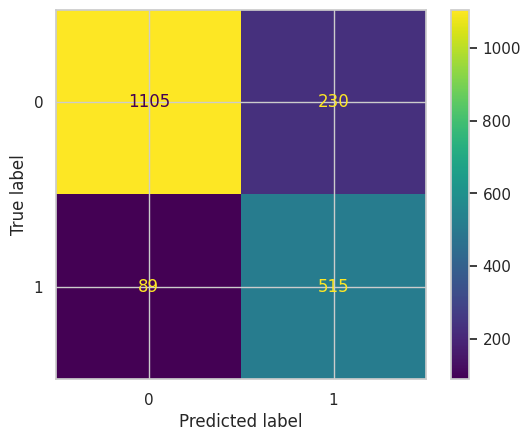

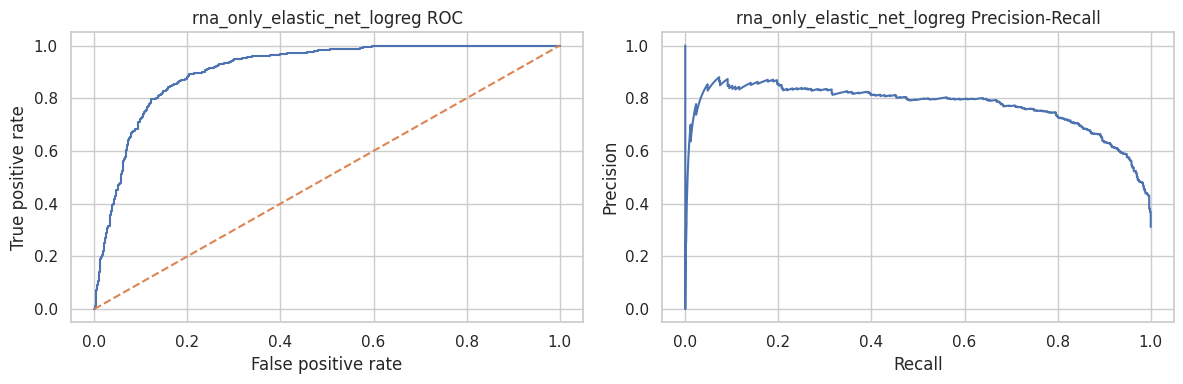

In [70]:
best_rna_artifact = rna_search["best_artifact"]
rna_test_proba = predict_rna_artifact(best_rna_artifact, X_rna_test)
rna_metrics = pd.Series({"model": "rna_only_elastic_net_logreg", **evaluate_from_proba(y_test, rna_test_proba)})

print()
print("rna_only_elastic_net_logreg")
display(rna_metrics.to_frame("value"))

rna_test_pred = (rna_test_proba >= 0.5).astype(int)
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, rna_test_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
print("Classification report at fixed threshold 0.5:")
print(classification_report(y_test, rna_test_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, rna_test_pred)
plt.show()
plot_roc_pr_curves(y_test, rna_test_proba, title_prefix="rna_only_elastic_net_logreg")

## Holdout comparison and calibration diagnostics

,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,rna_only_elastic_net_logreg,0.908491,0.769996,0.840182,0.763529,0.120695
1,dummy_prior,0.500000,0.311501,0.500000,0.000000,0.214468


,model,auroc_ci_2.5,auroc_ci_50,auroc_ci_97.5,auprc_ci_2.5,auprc_ci_50,auprc_ci_97.5
0,rna_only_elastic_net_logreg,0.895549,0.908046,0.922525,0.731342,0.769976,0.815197


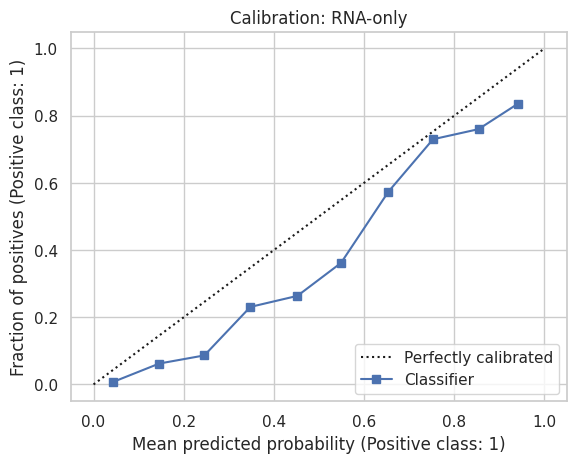

In [71]:
holdout_results = pd.DataFrame([dummy_metrics, rna_metrics])
holdout_results = holdout_results.sort_values("auprc", ascending=False).reset_index(drop=True)
display(holdout_results)

ci_rows = []
for model_name, proba in [
    ("rna_only_elastic_net_logreg", rna_test_proba),
]:
    auroc_lo, auroc_med, auroc_hi = bootstrap_metric_ci(y_test, proba, roc_auc_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    auprc_lo, auprc_med, auprc_hi = bootstrap_metric_ci(y_test, proba, average_precision_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    ci_rows.append({
        "model": model_name,
        "auroc_ci_2.5": auroc_lo,
        "auroc_ci_50": auroc_med,
        "auroc_ci_97.5": auroc_hi,
        "auprc_ci_2.5": auprc_lo,
        "auprc_ci_50": auprc_med,
        "auprc_ci_97.5": auprc_hi,
    })

holdout_ci = pd.DataFrame(ci_rows)
display(holdout_ci)

CalibrationDisplay.from_predictions(y_test, rna_test_proba, n_bins=10)
plt.title("Calibration: RNA-only")
plt.show()


## Task 2: multiclass TP53 mutation-type prediction with cancer-type-stratified splitting

This section addresses the assignment's mutation-type task in TCGA. It predicts broad TP53 mutation-type/consequence classes from RNA expression:

- `WT`;
- `missense`;
- `truncating_or_splice`.

Cancer type is used for stratified splitting and auditing only. It is not included as a feature in the primary RNA model. The Task 2 split is stratified by **mutation-type class x cancer type** where feasible so that both mutation-type prevalence and cancer-type composition are reasonably balanced between train and test.

The 3-class TCGA Task 2 result should be interpreted more cautiously than the CCLE result. TCGA is pan-cancer, tumor samples are biologically heterogeneous, and the mutation-type classes are imbalanced. In the held-out test set, the model performs well on the WT class but has lower F1 for `missense` and especially `truncating_or_splice`. This is expected because distinguishing mutation mechanisms or consequence classes from bulk RNA expression is harder than detecting broad mutant-vs-WT status.

The notebook also computes a strict **mutant-only Task 2** report on TP53-mutant held-out samples only, comparing `missense` versus `truncating_or_splice`. This directly addresses a strict interpretation of "type of mutation." In this evaluation, WT predictions made by the 3-class model on mutant samples are counted as errors in the metrics. The mutant-only confusion table focuses on the two mutant classes, so the full 3-class confusion matrix should be considered when interpreting WT-predicted errors.

In [72]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in TCGA
# ============================================================
# Methodological changes from the initial completed version:
#   * The Task 2 train/test split is stratified by mutation-type label and cancer type.
#   * Cancer type is the TCGA analogue of CCLE lineage.
#   * The model chosen for detailed reporting is selected by CV macro-F1, not by test macro-F1.
#   * Cancer type is used for stratification/auditing only, not as a predictor.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize



def make_stable_joint_strata(
    labels,
    groups,
    min_count=2,
    group_name="group",
    split_fraction=None,
    min_group_count=10,
    max_unique_strata=None,
):
    """Create adaptive label x group strata without dropping samples.

    Strict label-by-lineage strata can be too granular when some lineages or
    label-lineage cells are small. This helper keeps all samples, collapses
    rare groups/cells into a rare bucket, and only falls back to label-only
    stratification if the joint strata are still unsafe for the requested split.

    Parameters
    ----------
    labels : array-like
        Target labels used for stratification.
    groups : array-like
        Lineage/cancer-type groups used as strata, not predictors.
    min_count : int
        Minimum count required in each final stratum. For k-fold CV, pass k.
    split_fraction : float or None
        Fraction used for the smaller split. When provided, the helper also
        limits the number of unique strata so sklearn can allocate at least one
        sample per stratum in the split.
    min_group_count : int
        Overall group size below which a lineage/cancer type is collapsed to a
        rare bucket before constructing label x group strata.
    """
    labels = pd.Series(labels).astype(str)
    groups = (
        pd.Series(groups, index=labels.index)
        .astype(str)
        .fillna("missing")
        .replace({"nan": "missing", "None": "missing"})
    )

    n = len(labels)
    min_count = int(max(2, min_count))

    if split_fraction is not None:
        split_fraction = float(split_fraction)
        n_small = int(np.ceil(n * min(split_fraction, 1 - split_fraction)))
        # sklearn requires n_train and n_test to be >= number of strata.
        max_unique_by_split = max(2, n_small)
    else:
        max_unique_by_split = n

    if max_unique_strata is None:
        max_unique_strata = max_unique_by_split
    else:
        max_unique_strata = min(int(max_unique_strata), max_unique_by_split)

    # Try increasingly broad rare-group collapses before falling back to labels only.
    candidate_min_group_counts = sorted(set([int(min_group_count), 15, 25, 40, 60, 100, 10**9]))

    for threshold in candidate_min_group_counts:
        group_counts = groups.value_counts(dropna=False)
        if threshold >= 10**9:
            groups_collapsed = pd.Series(f"RARE_{group_name.upper()}", index=groups.index)
        else:
            groups_collapsed = groups.where(groups.map(group_counts) >= threshold, f"RARE_{group_name.upper()}")

        joint = labels + "__" + groups_collapsed
        rare_joint = joint.value_counts(dropna=False).loc[lambda s: s < min_count].index
        if len(rare_joint) > 0:
            groups_collapsed = groups_collapsed.copy()
            groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
            joint = labels + "__" + groups_collapsed

        counts = joint.value_counts(dropna=False)
        if counts.min() >= min_count and counts.shape[0] <= max_unique_strata:
            print(
                f"Using adaptive TP53-label x {group_name} strata: "
                f"{counts.shape[0]} strata; rare {group_name} threshold={threshold}. "
                f"No samples dropped."
            )
            return joint

    print(
        f"Warning: TP53-label x {group_name} strata are too sparse for this split/CV; "
        "falling back to TP53-label-only stratification. No samples dropped."
    )
    return labels

def align_task2_proba_from_classes(raw_proba, est_classes, labels):
    labels = list(labels)
    est_classes = list(est_classes)
    out = np.zeros((raw_proba.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw_proba[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


def fit_multiclass_logreg_ready(X_train_ready, y_train, C, l1_ratio):
    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=SKLEARN_MAX_ITER,
        tol=SAGA_TOL,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        C=float(C),
        l1_ratio=float(l1_ratio),
    )
    clf.fit(np.asarray(X_train_ready, dtype=np.float64), y_train)
    return clf


def fit_task2_rna_logreg_artifact(X_train, y_train, params):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_multiclass_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
    )
    return {
        "kind": "task2_rna_logreg",
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }


def fit_task2_rna_rf_artifact(X_train, y_train, params):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = RandomForestClassifier(
        n_estimators=int(params.get("n_estimators", 400)),
        max_depth=params.get("max_depth", 16),
        min_samples_leaf=int(params.get("min_samples_leaf", 2)),
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_ready, y_train)
    return {
        "kind": "task2_rna_random_forest",
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }


def predict_task2_rna_artifact(artifact, X, labels):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    raw = artifact["model"].predict_proba(X_ready)
    return align_task2_proba_from_classes(raw, artifact["model"].classes_, labels)



def task2_cv_search(model_name, fit_fn, predict_fn, param_grid, X_fit, y_fit, labels, cv):
    rows = []
    best_score = -np.inf
    best_params = None

    for params in list(ParameterGrid(param_grid)):
        fold_scores = []
        for tr, va in cv:
            artifact = fit_fn(X_fit[tr], y_fit[tr], params)
            proba = predict_fn(artifact, X_fit[va], labels)
            metrics, _ = evaluate_multiclass(y_fit[va], proba, labels)
            fold_scores.append(metrics["macro_f1"])
            del artifact, proba
            gc.collect()

        mean_macro_f1 = float(np.mean(fold_scores))
        rows.append({
            "model": model_name,
            "params": dict(params),
            "cv_macro_f1": mean_macro_f1,
        })
        if mean_macro_f1 > best_score:
            best_score = mean_macro_f1
            best_params = dict(params)

    final_artifact = fit_fn(X_fit, y_fit, best_params)
    return {
        "model": model_name,
        "best_params": best_params,
        "best_cv_macro_f1": float(best_score),
        "cv_results": pd.DataFrame(rows),
        "artifact": final_artifact,
    }


task2_labels = ["WT", "missense", "truncating_or_splice"]

task2_indices = model_meta_task2.index.to_numpy()
X_rna_task2 = X_rna[task2_indices]
X_meta_task2 = model_meta_task2[[CANCER_TYPE_COL]].copy().reset_index(drop=True)  # split/audit only; not a predictor
X_meta_task2[CANCER_TYPE_COL] = X_meta_task2[CANCER_TYPE_COL].astype(str).fillna("missing").replace({"nan": "missing"})
y_task2 = model_meta_task2["TP53_task2_label"].astype(str).to_numpy()
groups_task2 = model_meta_task2[CANCER_TYPE_COL].astype(str).to_numpy()

task2_all_pos = np.arange(len(y_task2))
task2_strata_all = make_stable_joint_strata(
    labels=y_task2,
    groups=groups_task2,
    min_count=2,
    group_name="cancer_type",
    split_fraction=TASK2_TEST_SIZE,
    min_group_count=25,
)

task2_train_pos, task2_test_pos = train_test_split(
    task2_all_pos,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=task2_strata_all,
)

X2_train = X_rna_task2[task2_train_pos]
X2_test = X_rna_task2[task2_test_pos]
X2_meta_train = X_meta_task2.iloc[task2_train_pos]  # split/audit only
X2_meta_test = X_meta_task2.iloc[task2_test_pos]  # split/audit only
y2_train = y_task2[task2_train_pos]
y2_test = y_task2[task2_test_pos]
g2_train = groups_task2[task2_train_pos]
g2_test = groups_task2[task2_test_pos]

task2_split_counts = pd.concat(
    {
        "train": pd.Series(y2_train).value_counts().reindex(task2_labels),
        "test": pd.Series(y2_test).value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_cancer_split_counts = pd.concat(
    {
        "train": pd.Series(g2_train).value_counts(),
        "test": pd.Series(g2_test).value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("TCGA Task 2 split counts using label-cancer-type stratification:")
display(task2_split_counts)
print("TCGA Task 2 cancer-type split counts, top 20 cancer types:")
display(task2_cancer_split_counts.head(20))
print("Cancer types absent from Task 2 train but present in test:", sorted(set(g2_test) - set(g2_train)))
print("Cancer types absent from Task 2 test but present in train:", sorted(set(g2_train) - set(g2_test))[:10])

task2_cv_n = min(INNER_CV_SPLITS, int(pd.Series(y2_train).value_counts().min()))
task2_train_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=g2_train,
    min_count=task2_cv_n,
    group_name="cancer_type",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RANDOM_STATE).split(
        np.zeros(len(y2_train)),
        task2_train_cv_strata,
    )
)

TASK2_LOGREG_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.03, 0.1, 0.3],
    "l1_ratio": [0.0, 0.5],
}

TASK2_RF_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "n_estimators": [400],
    "max_depth": [12, 20],
    "min_samples_leaf": [2],
}

# Baseline 1: empirical class prior.
task2_dummy = DummyClassifier(strategy="prior")
task2_dummy.fit(np.zeros((len(y2_train), 1)), y2_train)
task2_dummy_raw = task2_dummy.predict_proba(np.zeros((len(y2_test), 1)))
task2_dummy_proba = align_task2_proba_from_classes(task2_dummy_raw, task2_dummy.classes_, task2_labels)
task2_dummy_metrics, task2_dummy_pred = evaluate_multiclass(y2_test, task2_dummy_proba, task2_labels)

# RNA-only models.
task2_logreg_search = task2_cv_search(
    "task2_rna_multinomial_logreg",
    fit_task2_rna_logreg_artifact,
    predict_task2_rna_artifact,
    TASK2_LOGREG_GRID,
    X2_train,
    y2_train,
    task2_labels,
    task2_cv,
)

task2_rf_search = task2_cv_search(
    "task2_rna_random_forest",
    fit_task2_rna_rf_artifact,
    predict_task2_rna_artifact,
    TASK2_RF_GRID,
    X2_train,
    y2_train,
    task2_labels,
    task2_cv,
)

# RNA + cancer-type model intentionally omitted; predictors remain RNA-only.
task2_combo_search = None

task2_rows = [
    {
        "model": "task2_dummy_prior",
        "tier": "baseline",
        "best_cv_macro_f1": np.nan,
        "selection_macro_f1": np.nan,
        "best_params": {},
        **{f"test_{k}": v for k, v in task2_dummy_metrics.items()},
    },
]

task2_predictions = {
    "task2_dummy_prior": task2_dummy_pred,
}
task2_artifacts = {
    "task2_rna_multinomial_logreg": task2_logreg_search["artifact"],
    "task2_rna_random_forest": task2_rf_search["artifact"],
}

for search in [task2_logreg_search, task2_rf_search]:
    proba = predict_task2_rna_artifact(search["artifact"], X2_test, task2_labels)
    metrics, pred = evaluate_multiclass(y2_test, proba, task2_labels)
    task2_rows.append({
        "model": search["model"],
        "tier": "rna_only",
        "best_cv_macro_f1": search["best_cv_macro_f1"],
        "selection_macro_f1": search["best_cv_macro_f1"],
        "best_params": search["best_params"],
        **{f"test_{k}": v for k, v in metrics.items()},
    })
    task2_predictions[search["model"]] = pred


tcga_task2_results = pd.DataFrame(task2_rows)
tcga_task2_results["selection_rank"] = tcga_task2_results["selection_macro_f1"].rank(
    method="first",
    ascending=False,
    na_option="bottom",
).astype(int)
tcga_task2_results = tcga_task2_results.sort_values("selection_rank").reset_index(drop=True)

display(tcga_task2_results)

selectable = tcga_task2_results.loc[tcga_task2_results["selection_macro_f1"].notna()].copy()
best_tcga_task2_model = selectable.iloc[0]["model"]
best_tcga_task2_pred = task2_predictions[best_tcga_task2_model]

tcga_task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_tcga_task2_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

tcga_task2_report = multiclass_report_df(
    y2_test,
    best_tcga_task2_pred,
    task2_labels,
)

print(f"Best TCGA Task 2 model by CV macro-F1: {best_tcga_task2_model}")
display(tcga_task2_confusion)
display(tcga_task2_report.round(4))

# Strict assignment-aligned Task 2: evaluate mutation type among TP53-mutant samples only.
# The fitted model and predictions are unchanged; WT test samples are removed only for this metric.
tcga_task2_mutant_labels = ["missense", "truncating_or_splice"]
tcga_task2_mutant_mask = pd.Series(y2_test).astype(str).ne("WT").to_numpy()
tcga_task2_mutant_y_true = pd.Series(y2_test).astype(str).to_numpy()[tcga_task2_mutant_mask]
tcga_task2_mutant_y_pred = pd.Series(best_tcga_task2_pred).astype(str).to_numpy()[tcga_task2_mutant_mask]

tcga_task2_mutant_only_metrics = pd.DataFrame([
    {
        "cohort": "TCGA",
        "evaluation": "mutant_only_task2",
        "best_model": best_tcga_task2_model,
        "n_mutant_test_samples": int(tcga_task2_mutant_mask.sum()),
        "labels": json.dumps(tcga_task2_mutant_labels),
        "accuracy": accuracy_score(tcga_task2_mutant_y_true, tcga_task2_mutant_y_pred),
        "balanced_accuracy": balanced_accuracy_score(tcga_task2_mutant_y_true, tcga_task2_mutant_y_pred),
        "macro_f1": f1_score(
            tcga_task2_mutant_y_true,
            tcga_task2_mutant_y_pred,
            average="macro",
            labels=tcga_task2_mutant_labels,
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            tcga_task2_mutant_y_true,
            tcga_task2_mutant_y_pred,
            average="weighted",
            labels=tcga_task2_mutant_labels,
            zero_division=0,
        ),
    }
])

tcga_task2_mutant_only_confusion = pd.DataFrame(
    confusion_matrix(
        tcga_task2_mutant_y_true,
        tcga_task2_mutant_y_pred,
        labels=tcga_task2_mutant_labels,
    ),
    index=[f"true_{x}" for x in tcga_task2_mutant_labels],
    columns=[f"pred_{x}" for x in tcga_task2_mutant_labels],
)

tcga_task2_mutant_only_report = multiclass_report_df(
    tcga_task2_mutant_y_true,
    tcga_task2_mutant_y_pred,
    tcga_task2_mutant_labels,
)

print("Strict TCGA Task 2 mutant-only evaluation: missense vs truncating/splice")
display(tcga_task2_mutant_only_metrics.round(4))
display(tcga_task2_mutant_only_confusion)
display(tcga_task2_mutant_only_report.round(4))

# Optional cancer-type-grouped check for Task 2.
# This is reported as a robustness check because mutation-type classes can be sparse in held-out cancer groups.
tcga_task2_grouped_results = pd.DataFrame()
tcga_task2_grouped_summary = pd.DataFrame()

min_task2_class_n = int(pd.Series(y_task2).value_counts().min())
n_grouped_splits = min(GROUP_CV_SPLITS, len(np.unique(groups_task2)), min_task2_class_n)

if n_grouped_splits >= 3:
    grouped_rows = []
    grouped_cv_task2 = StratifiedGroupKFold(
        n_splits=n_grouped_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    for fold, (tr, te) in enumerate(grouped_cv_task2.split(X_rna_task2, y_task2, groups_task2), start=1):
        y_tr, y_te = y_task2[tr], y_task2[te]
        if set(task2_labels) - set(y_tr) or set(task2_labels) - set(y_te):
            grouped_rows.append({
                "fold": fold,
                "model": "task2_rna_multinomial_logreg",
                "status": "skipped_missing_class_in_train_or_test",
                "n_test": len(te),
            })
            continue
        artifact = fit_task2_rna_logreg_artifact(
            X_rna_task2[tr],
            y_tr,
            task2_logreg_search["best_params"],
        )
        proba = predict_task2_rna_artifact(artifact, X_rna_task2[te], task2_labels)
        metrics, _ = evaluate_multiclass(y_te, proba, task2_labels)
        grouped_rows.append({
            "fold": fold,
            "model": "task2_rna_multinomial_logreg",
            "status": "ok",
            "n_test": len(te),
            **metrics,
        })
    tcga_task2_grouped_results = pd.DataFrame(grouped_rows)
    display(tcga_task2_grouped_results)
    ok_grouped = tcga_task2_grouped_results.loc[tcga_task2_grouped_results["status"].eq("ok")]
    if len(ok_grouped) > 0:
        tcga_task2_grouped_summary = ok_grouped.groupby("model")[[
            "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "ovr_auroc_macro", "ovr_auprc_macro"
        ]].agg(["mean", "std"])
        display(tcga_task2_grouped_summary)
else:
    print("Skipping TCGA Task 2 grouped CV because class or cancer-type support is too sparse.")

# Save Task 2 outputs immediately so they are available even if later optional sections are skipped.
task2_raw_counts.to_csv("tcga_task2_raw_class_counts.csv")
task2_candidate_counts.to_csv("tcga_task2_collapsed_class_counts.csv")
task2_split_counts.to_csv("tcga_task2_split_class_counts.csv")
task2_cancer_split_counts.to_csv("tcga_task2_cancer_type_split_counts.csv")
tcga_task2_results.to_csv("tcga_task2_test_results.csv", index=False)
tcga_task2_confusion.to_csv("tcga_task2_confusion_matrix.csv")
tcga_task2_report.to_csv("tcga_task2_classification_report.csv", index=False)
tcga_task2_mutant_only_metrics.to_csv("tcga_task2_mutant_only_metrics.csv", index=False)
tcga_task2_mutant_only_confusion.to_csv("tcga_task2_mutant_only_confusion_matrix.csv")
tcga_task2_mutant_only_report.to_csv("tcga_task2_mutant_only_classification_report.csv", index=False)

task2_cv_result_frames = [
    task2_logreg_search["cv_results"],
    task2_rf_search["cv_results"],
]
pd.concat(task2_cv_result_frames, ignore_index=True).to_csv("tcga_task2_cv_results.csv", index=False)

if len(tcga_task2_grouped_results) > 0:
    tcga_task2_grouped_results.to_csv("tcga_task2_grouped_cv_results.csv", index=False)
if len(tcga_task2_grouped_summary) > 0:
    tcga_task2_grouped_summary.to_csv("tcga_task2_grouped_cv_summary.csv")


Using adaptive TP53-label x cancer_type strata: 89 strata; rare cancer_type threshold=15. No samples dropped.
TCGA Task 2 split counts using label-cancer-type stratification:


,train,test
WT,5309,1327
missense,1518,380
truncating_or_splice,845,212


TCGA Task 2 cancer-type split counts, top 20 cancer types:


,train,test
BRCA,868,218
KIRC,423,106
THCA,404,100
HNSC,403,102
LGG,401,101
LUAD,400,101
PRAD,397,98
LUSC,379,95
SKCM,370,92
OV,338,84


Cancer types absent from Task 2 train but present in test: []
Cancer types absent from Task 2 test but present in train: []
Using adaptive TP53-label x cancer_type strata: 86 strata; rare cancer_type threshold=10. No samples dropped.


...

,cohort,evaluation,best_model,n_mutant_test_samples,labels,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,TCGA,mutant_only_task2,task2_rna_multinomial_logreg,592,"[""missense"", ""truncating_or_splice""]",0.4628,0.4544,0.4921,0.5123


,pred_missense,pred_truncating_or_splice
true_missense,184,126
true_truncating_or_splice,89,90


,class,precision,recall,f1-score,support
0,missense,0.6740,0.4842,0.5636,380.0
1,truncating_or_splice,0.4167,0.4245,0.4206,212.0
2,micro avg,0.5603,0.4628,0.5069,592.0
3,macro avg,0.5453,0.4544,0.4921,592.0
4,weighted avg,0.5818,0.4628,0.5123,592.0


,fold,model,status,n_test,accuracy,balanced_accuracy,macro_f1,weighted_f1,ovr_auroc_macro,ovr_auprc_macro
0,1,task2_rna_multinomial_logreg,ok,4164,0.615754,0.509778,0.501465,0.619429,0.726843,0.497797
1,2,task2_rna_multinomial_logreg,ok,2648,0.669184,0.474036,0.474213,0.668907,0.735142,0.480589
2,3,task2_rna_multinomial_logreg,ok,2779,0.578625,0.479318,0.403204,0.644642,0.704635,0.415548


accuracy           balanced_accuracy            macro_f1           weighted_f1           ovr_auroc_macro           ovr_auprc_macro          
                                  mean       std              mean       std      mean       std        mean       std            mean       std            mean       std
model                                                                                                                                                                     
task2_rna_multinomial_logreg  0.621188  0.045523           0.48771  0.019293  0.459627  0.050728    0.644326  0.024741        0.722207  0.015773        0.464645  0.043381

## Cancer-type-grouped RNA-only evaluation

This is the main anti-confounding section. Cancer type is used as the grouping variable for evaluation, not as a predictor. With `GROUPED_TUNING_MODE = "reuse_holdout_best"`, the grouped result is a practical robustness check; set `GROUPED_TUNING_MODE = "nested"` only if you have enough runtime for fully nested grouped tuning.


In [73]:
if RUN_GROUPED_CV:
    group_outer = StratifiedGroupKFold(
        n_splits=GROUP_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    group_inner = StratifiedGroupKFold(
        n_splits=max(3, GROUP_CV_SPLITS - 1),
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    group_rows = []

    for fold, (tr_idx, te_idx) in enumerate(group_outer.split(X_rna, y, groups), start=1):
        y_tr, y_te = y[tr_idx], y[te_idx]
        g_tr = groups[tr_idx]

        X_rna_tr = X_rna[tr_idx]
        X_rna_te = X_rna[te_idx]

        dummy = DummyClassifier(strategy="prior")
        dummy.fit(np.zeros((len(tr_idx), 1)), y_tr)
        dummy_proba = dummy.predict_proba(np.zeros((len(te_idx), 1)))[:, 1]
        group_rows.append({
            "fold": fold,
            "model": "dummy_prior",
            **evaluate_from_proba(y_te, dummy_proba),
        })

        if GROUPED_TUNING_MODE == "nested":
            rna_group_search = manual_cv_search_rna(
                X=X_rna_tr,
                y=y_tr,
                splitter=group_inner,
                param_grid=GROUPED_RNA_PARAM_GRID,
                search_backend=GPU_SEARCH_BACKEND,
                refit_backend=FINAL_REFIT_BACKEND,
                groups=g_tr,
                verbose=0,
                label=f"RNA_GROUP_FOLD_{fold}",
            )
            rna_group_artifact = rna_group_search["best_artifact"]
        else:
            rna_group_artifact = fit_rna_artifact(
                X_train=X_rna_tr,
                y_train=y_tr,
                params=rna_search["best_params"],
                backend=FINAL_REFIT_BACKEND,
            )
        rna_group_proba = predict_rna_artifact(rna_group_artifact, X_rna_te)
        group_rows.append({
            "fold": fold,
            "model": "rna_only_elastic_net_logreg",
            **evaluate_from_proba(y_te, rna_group_proba),
        })

        print(f"Completed grouped outer fold {fold}/{GROUP_CV_SPLITS}")

    group_results = pd.DataFrame(group_rows)
    display(group_results)

    group_summary = (
        group_results
        .groupby("model")[["auroc", "auprc", "balanced_accuracy_at_0.5", "f1_at_0.5", "brier"]]
        .agg(["mean", "std"])
    )
    display(group_summary)
else:
    print("RUN_GROUPED_CV is False; skipping grouped evaluation.")


Completed grouped outer fold 1/3
Completed grouped outer fold 2/3
Completed grouped outer fold 3/3


,fold,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,1,dummy_prior,0.500000,0.412194,0.500000,0.000000,0.266505
1,1,rna_only_elastic_net_logreg,0.808455,0.712629,0.679999,0.584602,0.185687
2,2,dummy_prior,0.500000,0.248983,0.500000,0.000000,0.196417
3,2,rna_only_elastic_net_logreg,0.717040,0.375241,0.625679,0.449173,0.226959
4,3,dummy_prior,0.500000,0.265841,0.500000,0.000000,0.199340
5,3,rna_only_elastic_net_logreg,0.819825,0.643773,0.741002,0.607450,0.164381


auroc               auprc          balanced_accuracy_at_0.5           f1_at_0.5               brier          
                                 mean       std      mean      std                     mean       std      mean       std      mean       std
model                                                                                                                                        
dummy_prior                  0.500000  0.000000  0.309006  0.08976                 0.500000  0.000000  0.000000  0.000000  0.220754  0.039648
rna_only_elastic_net_logreg  0.781773  0.056348  0.577214  0.17827                 0.682227  0.057694  0.547075  0.085552  0.192342  0.031815

## Inspect RNA coefficients and optional biological sanity checks

This section strips Ensembl version suffixes, optionally maps to gene symbols, and checks overlap with the TP53 target list when possible.

In [74]:
best_rna_preproc = best_rna_artifact["preproc"]
final_features = extract_rna_feature_names(best_rna_preproc, gene_ids)
coef = np.asarray(best_rna_artifact["model"].coef_).ravel()

coef_df = pd.DataFrame({
    "ensembl_gene_id": final_features,
    "coefficient": coef,
})
coef_df["ensembl_gene_id_no_version"] = coef_df["ensembl_gene_id"].astype(str).str.replace(r"\..*$", "", regex=True)

def infer_ensembl_col(df):
    candidates = [
        "ensembl_gene_id", "ensembl_gene_id_no_version", "Ensembl", "ENSEMBL",
        "gene_id", "id", "feature_id",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def infer_symbol_col(df):
    candidates = [
        "gene_symbol", "symbol", "gene", "Gene", "HugoSymbol", "hgnc_symbol",
        "approved_symbol", "gene_name",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def parse_symbol_from_feature_id(x):
    parts = [p.strip() for p in str(x).split("|")]
    for part in parts:
        if part and not looks_like_ensembl(part):
            return part
    return np.nan

# Fallback: if feature IDs themselves carry symbols, use them.
coef_df["gene_symbol"] = coef_df["ensembl_gene_id"].map(parse_symbol_from_feature_id)

annotation_loaded = False
if GENE_ANNOTATION_PATH is not None:
    gene_annot = pd.read_csv(GENE_ANNOTATION_PATH, sep=None, engine="python", low_memory=False)
    annot_ensembl_col = infer_ensembl_col(gene_annot)
    annot_symbol_col = infer_symbol_col(gene_annot)
    if annot_ensembl_col is not None and annot_symbol_col is not None:
        gene_map = gene_annot[[annot_ensembl_col, annot_symbol_col]].copy()
        gene_map.columns = ["ensembl_gene_id_raw", "gene_symbol_from_annotation"]
        gene_map["ensembl_gene_id_no_version"] = gene_map["ensembl_gene_id_raw"].astype(str).str.replace(r"\..*$", "", regex=True)
        gene_map = gene_map.dropna(subset=["gene_symbol_from_annotation"]).drop_duplicates("ensembl_gene_id_no_version")
        coef_df = coef_df.merge(
            gene_map[["ensembl_gene_id_no_version", "gene_symbol_from_annotation"]],
            on="ensembl_gene_id_no_version",
            how="left",
        )
        coef_df["gene_symbol"] = coef_df["gene_symbol"].fillna(coef_df["gene_symbol_from_annotation"])
        annotation_loaded = True

coef_df["is_tp53_target"] = False
if TP53_TARGETS_PATH is not None and TP53_TARGETS_PATH.exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH, low_memory=False)
    target_ensembl_col = infer_ensembl_col(tp53_targets)
    target_symbol_col = infer_symbol_col(tp53_targets)

    if target_ensembl_col is not None:
        target_ids = (
            tp53_targets[target_ensembl_col]
            .astype(str)
            .str.replace(r"\..*$", "", regex=True)
            .dropna()
            .unique()
        )
        coef_df["is_tp53_target"] = coef_df["ensembl_gene_id_no_version"].isin(target_ids)
    if target_symbol_col is not None:
        target_symbols = set(tp53_targets[target_symbol_col].astype(str).str.upper().dropna())
        coef_df["is_tp53_target"] = coef_df["is_tp53_target"] | coef_df["gene_symbol"].astype(str).str.upper().isin(target_symbols)

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)

print("Gene symbol annotation loaded:", annotation_loaded)
print("Top positive coefficients:")
display(coef_df.head(TOP_COEFS_TO_SHOW))

print("Top negative coefficients:")
display(coef_df.tail(TOP_COEFS_TO_SHOW).sort_values("coefficient"))

print("Largest absolute coefficients:")
display(coef_df.sort_values("abs_coefficient", ascending=False).head(TOP_COEFS_TO_SHOW))

print("TP53-target overlap among selected RNA features:", int(coef_df["is_tp53_target"].sum()))

canonical_tp53_pathway = ["TP53", "MDM2", "CDKN1A", "BAX", "DDB2", "XPC", "FDXR", "RPS27L", "DRAM1", "EDA2R"]
canonical_hits = coef_df.loc[coef_df["gene_symbol"].astype(str).str.upper().isin(canonical_tp53_pathway)].copy()
print("Canonical TP53 pathway genes selected:", len(canonical_hits))
display(canonical_hits.sort_values("abs_coefficient", ascending=False))

Gene symbol annotation loaded: False
Top positive coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
0,ENSG00000226251.5,0.273782,ENSG00000226251,NaN,False,0.273782
1,ENSG00000215221.2,0.267109,ENSG00000215221,NaN,False,0.267109
2,ENSG00000259803.6,0.253814,ENSG00000259803,NaN,False,0.253814
3,ENSG00000184697.6,0.236366,ENSG00000184697,NaN,False,0.236366
4,ENSG00000184486.8,0.232791,ENSG00000184486,NaN,False,0.232791
5,ENSG00000240990.9,0.229591,ENSG00000240990,NaN,False,0.229591
6,ENSG00000187527.10,0.211617,ENSG00000187527,NaN,False,0.211617
7,ENSG00000270460.1,0.187954,ENSG00000270460,NaN,False,0.187954
8,ENSG00000171124.12,0.178542,ENSG00000171124,NaN,False,0.178542
9,ENSG00000103460.16,0.175351,ENSG00000103460,NaN,False,0.175351


Top negative coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
999,ENSG00000251095.6,-0.691968,ENSG00000251095,NaN,False,0.691968
998,ENSG00000250337.5,-0.689434,ENSG00000250337,NaN,False,0.689434
997,ENSG00000205592.13,-0.291071,ENSG00000205592,NaN,False,0.291071
996,ENSG00000105278.10,-0.265551,ENSG00000105278,NaN,False,0.265551
995,ENSG00000269941.1,-0.245882,ENSG00000269941,NaN,False,0.245882
994,ENSG00000176769.9,-0.217584,ENSG00000176769,NaN,False,0.217584
993,ENSG00000081479.12,-0.203995,ENSG00000081479,NaN,False,0.203995
992,ENSG00000197084.5,-0.198228,ENSG00000197084,NaN,False,0.198228
991,ENSG00000253764.1,-0.196143,ENSG00000253764,NaN,False,0.196143
990,ENSG00000143217.8,-0.193683,ENSG00000143217,NaN,False,0.193683


Largest absolute coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
999,ENSG00000251095.6,-0.691968,ENSG00000251095,NaN,False,0.691968
998,ENSG00000250337.5,-0.689434,ENSG00000250337,NaN,False,0.689434
997,ENSG00000205592.13,-0.291071,ENSG00000205592,NaN,False,0.291071
0,ENSG00000226251.5,0.273782,ENSG00000226251,NaN,False,0.273782
1,ENSG00000215221.2,0.267109,ENSG00000215221,NaN,False,0.267109
996,ENSG00000105278.10,-0.265551,ENSG00000105278,NaN,False,0.265551
2,ENSG00000259803.6,0.253814,ENSG00000259803,NaN,False,0.253814
995,ENSG00000269941.1,-0.245882,ENSG00000269941,NaN,False,0.245882
3,ENSG00000184697.6,0.236366,ENSG00000184697,NaN,False,0.236366
4,ENSG00000184486.8,0.232791,ENSG00000184486,NaN,False,0.232791


TP53-target overlap among selected RNA features: 0
Canonical TP53 pathway genes selected: 0


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient


## Combined model on the random holdout

This tests whether adding cancer type to RNA improves random-holdout performance.

In [75]:
# Combined RNA + cancer-type model intentionally disabled/omitted.
# Cancer type is used for stratification and auditing only, not as a predictor.
combo_search = None
best_combo_artifact = None
combo_test_proba = None
combo_metrics = None
print("Skipping RNA + cancer-type combined model by design; predictors remain RNA-only.")


Skipping RNA + cancer-type combined model by design; predictors remain RNA-only.


## TCGA RNA-only ablation and soft-voting ensemble

This section is enabled by default. It fits RNA-only ablation candidates using the available GPU backend when possible, falls back safely when needed, and then builds a soft-voting ensemble from the top ablation models. Cancer type is used only for stratification/grouped evaluation, not as a predictor.


In [76]:
# ============================================================
# TCGA RNA-only ablation table: GPU if available, CPU-safe fallback
# ============================================================

import time
import gc

RUN_RNA_ABLATION = True
ABLATION_ENSEMBLE_TOP_N = 3
ABLATION_BACKEND = "cuml" if GPU_AVAILABLE and cuLogisticRegression is not None else "sklearn"

print("RUN_RNA_ABLATION:", RUN_RNA_ABLATION)
print("Ablation backend:", ABLATION_BACKEND, "(cancer type is not used as a predictor)")

# X_rna is already feature-capped for TCGA. Keep every ablation top_k within the
# currently materialized TCGA RNA matrix and refit on TCGA train only. This avoids
# accidentally using stale CCLE globals such as X_trainval/y_trainval.
TCGA_ABLATION_TOP_K = int(min(TOP_VAR_GENES, X_rna_train.shape[1]))
print("TCGA ablation top_k capped at:", TCGA_ABLATION_TOP_K)

ablation_searches = {}
ablation_cv_results = pd.DataFrame()
ablation_test_scores = {}
ablation_table = pd.DataFrame()
ablation_failures = {}

if RUN_RNA_ABLATION:
    # Fixed, compact RNA-only candidates. These are deliberately small to keep Kaggle runtime feasible.
    # They still test preprocessing/model-regularization sensitivity without using metadata features.
    ABLATION_CANDIDATES = [
        {
            "model": "ablation_enet_sparse_500",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 500, "scaler": "maxabs", "C": 0.1, "l1_ratio": 0.5},
        },
        {
            "model": "ablation_l2_500",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 500, "scaler": "maxabs", "C": 0.1, "l1_ratio": 0.0},
        },
        {
            "model": "ablation_l2_1000",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 1000, "scaler": "maxabs", "C": 0.1, "l1_ratio": 0.0},
        },
        {
            "model": "ablation_enet_1000_highC",
            "params": {"top_k": TCGA_ABLATION_TOP_K, "k_select": 1000, "scaler": "maxabs", "C": 1.0, "l1_ratio": 0.5},
        },
    ]

    rows = []
    cv_rows = []
    for candidate in ABLATION_CANDIDATES:
        model_name = candidate["model"]
        params = candidate["params"]
        start = time.time()
        print(f"Running RNA-only ablation candidate: {model_name} | {params}")
        try:
            fold_metrics = crossval_fixed_rna_params(
                X=X_rna_train,
                y=y_train,
                splitter=inner_cv,
                params=params,
                backend=ABLATION_BACKEND,
                groups=None,
            )
            mean_cv_auprc = float(fold_metrics["auprc"].mean())
            mean_cv_auroc = float(fold_metrics["auroc"].mean())
            std_cv_auprc = float(fold_metrics["auprc"].std())
            fold_metrics.insert(0, "model", model_name)
            fold_metrics["params"] = json.dumps(params)
            cv_rows.append(fold_metrics)

            artifact = fit_rna_artifact(
                X_train=X_rna_train,
                y_train=y_train,
                params=params,
                backend=FINAL_REFIT_BACKEND,
            )
            test_score = predict_rna_artifact(artifact, X_rna_test)
            ablation_test_scores[model_name] = test_score
            test_metrics = evaluate_from_proba(y_test, test_score)

            ablation_searches[model_name] = {"best_score": mean_cv_auprc, "best_params": params}
            rows.append({
                "model": model_name,
                "backend_for_cv": ABLATION_BACKEND,
                "best_cv_auprc": mean_cv_auprc,
                "cv_auroc": mean_cv_auroc,
                "cv_auprc_std": std_cv_auprc,
                "best_params": params,
                "seconds": time.time() - start,
                **{f"test_{k}": v for k, v in test_metrics.items()},
            })
            del artifact, test_score
            gc.collect()
            if cp is not None:
                try:
                    cp.get_default_memory_pool().free_all_blocks()
                except Exception:
                    pass
        except Exception as exc:
            ablation_failures[model_name] = repr(exc)
            print(f"Ablation candidate failed and will be skipped: {model_name}: {repr(exc)}")

    ablation_cv_results = pd.concat(cv_rows, ignore_index=True) if len(cv_rows) else pd.DataFrame()
    ablation_table = (
        pd.DataFrame(rows)
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
        if len(rows)
        else pd.DataFrame()
    )

    print("TCGA RNA-only ablation table, selected without metadata predictors:")
    display(ablation_table)

    if len(ablation_cv_results):
        ablation_cv_results.to_csv("tcga_rna_ablation_cv_results.csv", index=False)
    if len(ablation_table):
        ablation_table.to_csv("tcga_rna_model_ablation_table.csv", index=False)
    if ablation_failures:
        print("Ablation failures/skips:")
        for name, err in ablation_failures.items():
            print(f" - {name}: {err}")
else:
    print("RUN_RNA_ABLATION is False; skipping RNA ablation table.")


RUN_RNA_ABLATION: True
Ablation backend: cuml (cancer type is not used as a predictor)
TCGA ablation top_k capped at: 3000
Running RNA-only ablation candidate: ablation_enet_sparse_500 | {'top_k': 3000, 'k_select': 500, 'scaler': 'maxabs', 'C': 0.1, 'l1_ratio': 0.5}
Running RNA-only ablation candidate: ablation_l2_500 | {'top_k': 3000, 'k_select': 500, 'scaler': 'maxabs', 'C': 0.1, 'l1_ratio': 0.0}
Running RNA-only ablation candidate: ablation_l2_1000 | {'top_k': 3000, 'k_select': 1000, 'scaler': 'maxabs', 'C': 0.1, 'l1_ratio': 0.0}
Running RNA-only ablation candidate: ablation_enet_1000_highC | {'top_k': 3000, 'k_select': 1000, 'scaler': 'maxabs', 'C': 1.0, 'l1_ratio': 0.5}
TCGA RNA-only ablation table, selected without metadata predictors:


,model,backend_for_cv,best_cv_auprc,cv_auroc,cv_auprc_std,best_params,seconds,test_auroc,test_auprc,test_balanced_accuracy_at_0.5,test_f1_at_0.5,test_brier
0,ablation_l2_1000,cuml,0.771524,0.895465,0.007238,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm...",13.346067,0.903043,0.766962,0.834683,0.757848,0.123513
1,ablation_enet_sparse_500,cuml,0.771029,0.896705,0.006072,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma...",8.772050,0.904068,0.759300,0.832219,0.753516,0.122954
2,ablation_l2_500,cuml,0.767440,0.893834,0.010909,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma...",6.679006,0.900504,0.753499,0.826937,0.748687,0.124719
3,ablation_enet_1000_highC,cuml,0.747419,0.879485,0.010160,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm...",44.074928,0.893344,0.753034,0.817003,0.737320,0.132337


### Soft-voting ensemble and final ablation comparison

The ensemble is selected without looking at test labels: the top RNA-only models by inner-CV AUPRC are averaged with uniform weights. This tests whether RNA model diversity improves held-out AUPRC beyond the main elastic-net model.


In [77]:
# ============================================================
# Soft-voting ensemble and final comparison table
# ============================================================

if RUN_RNA_ABLATION and len(ablation_table) > 0:
    top_ensemble_models = (
        ablation_table
        .sort_values("best_cv_auprc", ascending=False)
        .head(min(ABLATION_ENSEMBLE_TOP_N, len(ablation_table)))["model"]
        .tolist()
    )

    print("Soft-voting ensemble members selected by inner-CV AUPRC:")
    print(top_ensemble_models)

    ensemble_test_score = np.mean(
        [ablation_test_scores[m] for m in top_ensemble_models],
        axis=0,
    )
    ensemble_metrics = evaluate_from_proba(y_test, ensemble_test_score)

    ensemble_row = {
        "model": f"soft_vote_top{len(top_ensemble_models)}_by_cv_auprc",
        "best_cv_auprc": float(np.mean([ablation_searches[m]["best_score"] for m in top_ensemble_models])),
        "best_params": {
            "members": top_ensemble_models,
            "weights": "uniform",
            "selection_rule": "top models by inner-CV AUPRC",
        },
        **{f"test_{k}": v for k, v in ensemble_metrics.items()},
    }

    ablation_table_with_ensemble = (
        pd.concat([ablation_table, pd.DataFrame([ensemble_row])], ignore_index=True)
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
    )

    # Recompute the holdout dummy score because the grouped-CV section reuses the variable name dummy_proba.
    holdout_dummy_score = np.repeat(float(np.mean(y_train)), len(y_test))

    main_rows_for_ablation = []
    existing_model_scores = {
        "dummy_prior": holdout_dummy_score,
        "main_rna_elastic_net_logreg": rna_test_proba,
    }

    for model_name, score in existing_model_scores.items():
        metrics = evaluate_from_proba(y_test, score)
        main_rows_for_ablation.append({
            "model": model_name,
            "model_family": "main_notebook_model",
            "best_cv_auprc": np.nan,
            "best_params": np.nan,
            **{f"test_{k}": v for k, v in metrics.items()},
        })

    ablation_rows_clean = ablation_table_with_ensemble.copy()
    ablation_rows_clean["model_family"] = "rna_ablation"

    final_ablation_table = pd.concat(
        [pd.DataFrame(main_rows_for_ablation), ablation_rows_clean],
        ignore_index=True,
    )

    preferred_cols = [
        "model",
        "model_family",
        "best_cv_auprc",
        "test_auprc",
        "test_auroc",
        "test_balanced_accuracy_at_0.5",
        "test_f1_at_0.5",
        "test_brier",
        "best_params",
    ]

    final_ablation_table = (
        final_ablation_table[preferred_cols]
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
    )

    print("Final holdout comparison including main models, RNA ablations, and soft-voting ensemble:")
    display(final_ablation_table)

    final_ablation_table.to_csv("tcga_rna_model_ablation_table.csv", index=False)
    if len(ablation_cv_results):
        ablation_cv_results.to_csv("tcga_rna_model_ablation_cv_results.csv", index=False)
    print("Saved final ablation outputs to tcga_rna_model_ablation_table.csv and tcga_rna_model_ablation_cv_results.csv")
else:
    top_ensemble_models = []
    ablation_table_with_ensemble = pd.DataFrame()
    final_ablation_table = pd.DataFrame()
    print("RNA ablation was skipped or no ablation model succeeded; no ensemble/final ablation table created.")


Soft-voting ensemble members selected by inner-CV AUPRC:
['ablation_l2_1000', 'ablation_enet_sparse_500', 'ablation_l2_500']
Final holdout comparison including main models, RNA ablations, and soft-voting ensemble:


,model,model_family,best_cv_auprc,test_auprc,test_auroc,test_balanced_accuracy_at_0.5,test_f1_at_0.5,test_brier,best_params
0,main_rna_elastic_net_logreg,main_notebook_model,NaN,0.769996,0.908491,0.840182,0.763529,0.120695,NaN
1,ablation_l2_1000,rna_ablation,0.771524,0.766962,0.903043,0.834683,0.757848,0.123513,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm..."
2,soft_vote_top3_by_cv_auprc,rna_ablation,0.769998,0.766553,0.908159,0.846313,0.773998,0.118910,"{'members': ['ablation_l2_1000', 'ablation_ene..."
3,ablation_enet_sparse_500,rna_ablation,0.771029,0.759300,0.904068,0.832219,0.753516,0.122954,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma..."
4,ablation_l2_500,rna_ablation,0.767440,0.753499,0.900504,0.826937,0.748687,0.124719,"{'top_k': 3000, 'k_select': 500, 'scaler': 'ma..."
5,ablation_enet_1000_highC,rna_ablation,0.747419,0.753034,0.893344,0.817003,0.737320,0.132337,"{'top_k': 3000, 'k_select': 1000, 'scaler': 'm..."
6,dummy_prior,main_notebook_model,NaN,0.311501,0.500000,0.500000,0.000000,0.214468,NaN


Saved final ablation outputs to tcga_rna_model_ablation_table.csv and tcga_rna_model_ablation_cv_results.csv


## Within-cancer RNA evaluation

This asks whether the RNA model still carries TP53 signal **within individual tumour types**, not just across pan-cancer mixtures.

In [78]:
if RUN_WITHIN_CANCER_EVAL:
    within_cancer_rows = []
    for cancer_type, idx in model_meta.groupby(CANCER_TYPE_COL).groups.items():
        idx = np.array(list(idx))
        y_sub = y[idx]
        counts = pd.Series(y_sub).value_counts()
        n_neg = int(counts.get(0, 0))
        n_pos = int(counts.get(1, 0))
        if n_neg < MIN_SAMPLES_PER_CLASS or n_pos < MIN_SAMPLES_PER_CLASS:
            continue

        cv_splits = min(5, n_neg, n_pos)
        if cv_splits < 3:
            continue

        sub_cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        sub_scores = crossval_fixed_rna_params(
            X=X_rna[idx],
            y=y_sub,
            splitter=sub_cv,
            params=rna_search["best_params"],
            backend=WITHIN_CANCER_BACKEND,
        )

        within_cancer_rows.append({
            "cancer_type": cancer_type,
            "n_samples": len(idx),
            "n_pos": n_pos,
            "n_neg": n_neg,
            "prevalence": n_pos / len(idx),
            "cv_auroc_mean": float(sub_scores["auroc"].mean()),
            "cv_auroc_std": float(sub_scores["auroc"].std(ddof=0)),
            "cv_auprc_mean": float(sub_scores["auprc"].mean()),
            "cv_auprc_std": float(sub_scores["auprc"].std(ddof=0)),
            "cv_balanced_accuracy_at_0.5_mean": float(sub_scores["balanced_accuracy_at_0.5"].mean()),
        })

    within_cancer_df = pd.DataFrame(within_cancer_rows).sort_values("cv_auprc_mean", ascending=False)
    display(within_cancer_df)

    if len(within_cancer_df) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(within_cancer_df["n_samples"], within_cancer_df["cv_auprc_mean"])
        for _, row in within_cancer_df.iterrows():
            plt.text(row["n_samples"], row["cv_auprc_mean"], row["cancer_type"], fontsize=8)
        plt.xlabel("Number of samples")
        plt.ylabel("Within-cancer CV AUPRC")
        plt.title("Within-cancer RNA performance by tumour type")
        plt.show()
else:
    print("RUN_WITHIN_CANCER_EVAL is False; skipping within-cancer evaluation.")

RUN_WITHIN_CANCER_EVAL is False; skipping within-cancer evaluation.


## Final conclusions and exam-defense summary

This notebook addresses both required coursework tasks using gene expression profiles as predictors and TP53 mutation annotations as labels.

### Task 1: TP53 mutant versus wild type

Task 1 is formulated as binary classification: TP53 protein-altering/nonsynonymous mutant versus TP53 wild type or non-protein-altering status. The labels are constructed from somatic mutation annotations, not from RNA expression. The primary predictors are RNA expression measurements across genes.

The binary task is the most statistically stable part of the project. It has larger class support than the mutation-type task and asks a clearer biological question: whether RNA expression contains signal associated with TP53 mutation status. In both CCLE and TCGA, RNA-only models outperform simple baselines, supporting the conclusion that transcriptomic profiles contain predictive information about TP53 mutation status.

### Task 2: TP53 mutation type

Task 2 is implemented as coarse TP53 mutation-type/consequence prediction. The teaching material describes many mutation categories, including missense, nonsense, insertion, deletion, frameshift, and splice-site mutations. Instead of modelling every raw category separately, I grouped related annotations into broader classes with enough sample support.

In CCLE, the main classes are `wild_type`, `missense_or_inframe`, and `lof_or_splice`. In TCGA, the main classes are `WT`, `missense`, and `truncating_or_splice`. These classes capture an important biological distinction: missense/in-frame alterations often preserve protein length but alter sequence or local structure, whereas truncating, frameshift, nonsense, and splice-related events are more likely to severely disrupt TP53 function.

Because the phrase "type of mutation" can be interpreted strictly as a mutant-only task, the notebook also reports strict mutant-only Task 2 evaluations. These remove WT samples from the evaluation and compare the main mutant classes only. This makes the assignment alignment explicit while still preserving the broader 3-class status/type formulation.

### Splitting and confounding

Both datasets require careful splitting because cancer lineage or cancer type can confound the relationship between RNA expression and TP53 mutation. Gene expression is highly tissue-specific, and TP53 mutation prevalence differs across cancer types. Therefore, the notebook uses adaptive label-by-lineage or label-by-cancer-type stratification where feasible. Rare strata are collapsed rather than forcing unstable splits.

This stratification is used to balance train/test composition, not to train separate models within each lineage or cancer type. Rare lineages or cancer types may still have too few samples for reliable subgroup-specific conclusions. For this reason, the notebook also includes lineage/cancer-type audits, grouped evaluation, and model-family ablations.

### Leakage control

Mutation annotation columns are used only to define TP53 labels and are not included as RNA predictors. Supervised feature selection, scaling, and model fitting are performed within training or cross-validation workflows. The TCGA RNA loader uses an unsupervised high-variance feature cap for memory management, but this step does not use TP53 labels. This caveat should be distinguished from supervised leakage.

### Interpretation

The strongest scientific conclusion is that RNA expression contains predictive signal for TP53 mutation status. The project does not prove that selected genes causally determine TP53 mutation status. Important genes may reflect TP53 pathway activity, DNA-damage response, cell-cycle effects, cancer lineage, proliferation, or dataset-specific structure.

Task 2 should be interpreted more cautiously than Task 1. Mutation-type classes are smaller and more imbalanced, and different TP53 mutation types may produce overlapping downstream RNA effects. Therefore, macro-F1, balanced accuracy, per-class F1, and confusion matrices are more informative than accuracy alone.

Overall, the project satisfies the assignment by building and evaluating RNA-based models for both binary TP53 mutation status and TP53 mutation-type/consequence prediction, while explicitly addressing leakage, lineage/cancer-type confounding, class imbalance, and cautious biological interpretation.